# Automated Gastropod Species Classification Using Deep Learning

Ramirez, E.S.,

Tejol, M.J.O.,

Huerta, D.C.B.,

Mahinay, C.O.

YOLOv8 Instance Segmentation Augmented

**Prepare GPU**

In [ ]:
!nvidia-smi

Sun Mar 24 13:32:38 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              11W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


**Install YOLOv8**

In [ ]:
# Pip install method (recommended)

!pip install ultralytics==8.0.196

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
Setup complete ✅ (8 CPUs, 51.0 GB RAM, 28.9/201.2 GB disk)


In [ ]:
# Git clone method (for development)

# %cd {HOME}
# !git clone github.com/ultralytics/ultralytics
# %cd {HOME}/ultralytics
# !pip install -e .

# from IPython import display
# display.clear_output()

# import ultralytics
# ultralytics.checks()

In [ ]:
from ultralytics import YOLO

from IPython.display import display, Image

**Preparing Gastropod dataset from Roboflow**

In [ ]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="nnr60IqsdrtdXhoH1rQZ")
project = rf.workspace("gastropod").project("species_gastropod-seg")
version = project.version(3)
dataset = version.download("yolov8")

/content/datasets
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.3/158.3 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 26.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 9.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 MB 33.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.9.0.80
    Uninstalling opencv-python-headless-4.9.0.80:
      Successfully uninstalled opencv-python-headless-4.9.0.80
  Attempting uninstall: idna
    Found existing installation: idna 3.6
    Uninstalling idna-3.6:
      Successfully uninstalled idna-3.6
  Attempting uninstall: cycler
    Found existing installation: cycler 0.12.1
    Uninstalling cycler-0.12.1:
      Successfully uni

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Species_Gastropod-Seg-3 in yolov8:: 100%|██████████| 11052/11052 [00:01<00:00, 8972.86it/s]


# **Train INSTANCE SEGMENTATION Gastropod dataset**

In [ ]:
%cd {HOME}

!yolo task=segment mode=train model=yolov8s-seg.pt data={dataset.location}/data.yaml epochs=100 imgsz=640

/content
100% 22.8M/22.8M [00:00<00:00, 349MB/s]
New https://pypi.org/project/ultralytics/8.1.33 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
engine/trainer: task=segment, mode=train, model=yolov8s-seg.pt, data=/content/datasets/Species_Gastropod-Seg-3/data.yaml, epochs=100, patience=50, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=None, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_str

**Results**

In [ ]:
!ls {HOME}/runs/segment/train/

args.yaml					    MaskF1_curve.png	  train_batch27182.jpg
BoxF1_curve.png					    MaskP_curve.png	  train_batch2.jpg
BoxP_curve.png					    MaskPR_curve.png	  val_batch0_labels.jpg
BoxPR_curve.png					    MaskR_curve.png	  val_batch0_pred.jpg
BoxR_curve.png					    results.csv		  val_batch1_labels.jpg
confusion_matrix_normalized.png			    results.png		  val_batch1_pred.jpg
confusion_matrix.png				    train_batch0.jpg	  val_batch2_labels.jpg
events.out.tfevents.1711287291.76e9ff9916c1.2756.0  train_batch1.jpg	  val_batch2_pred.jpg
labels_correlogram.jpg				    train_batch27180.jpg  weights
labels.jpg					    train_batch27181.jpg


## **Confusion Matrix**

/content


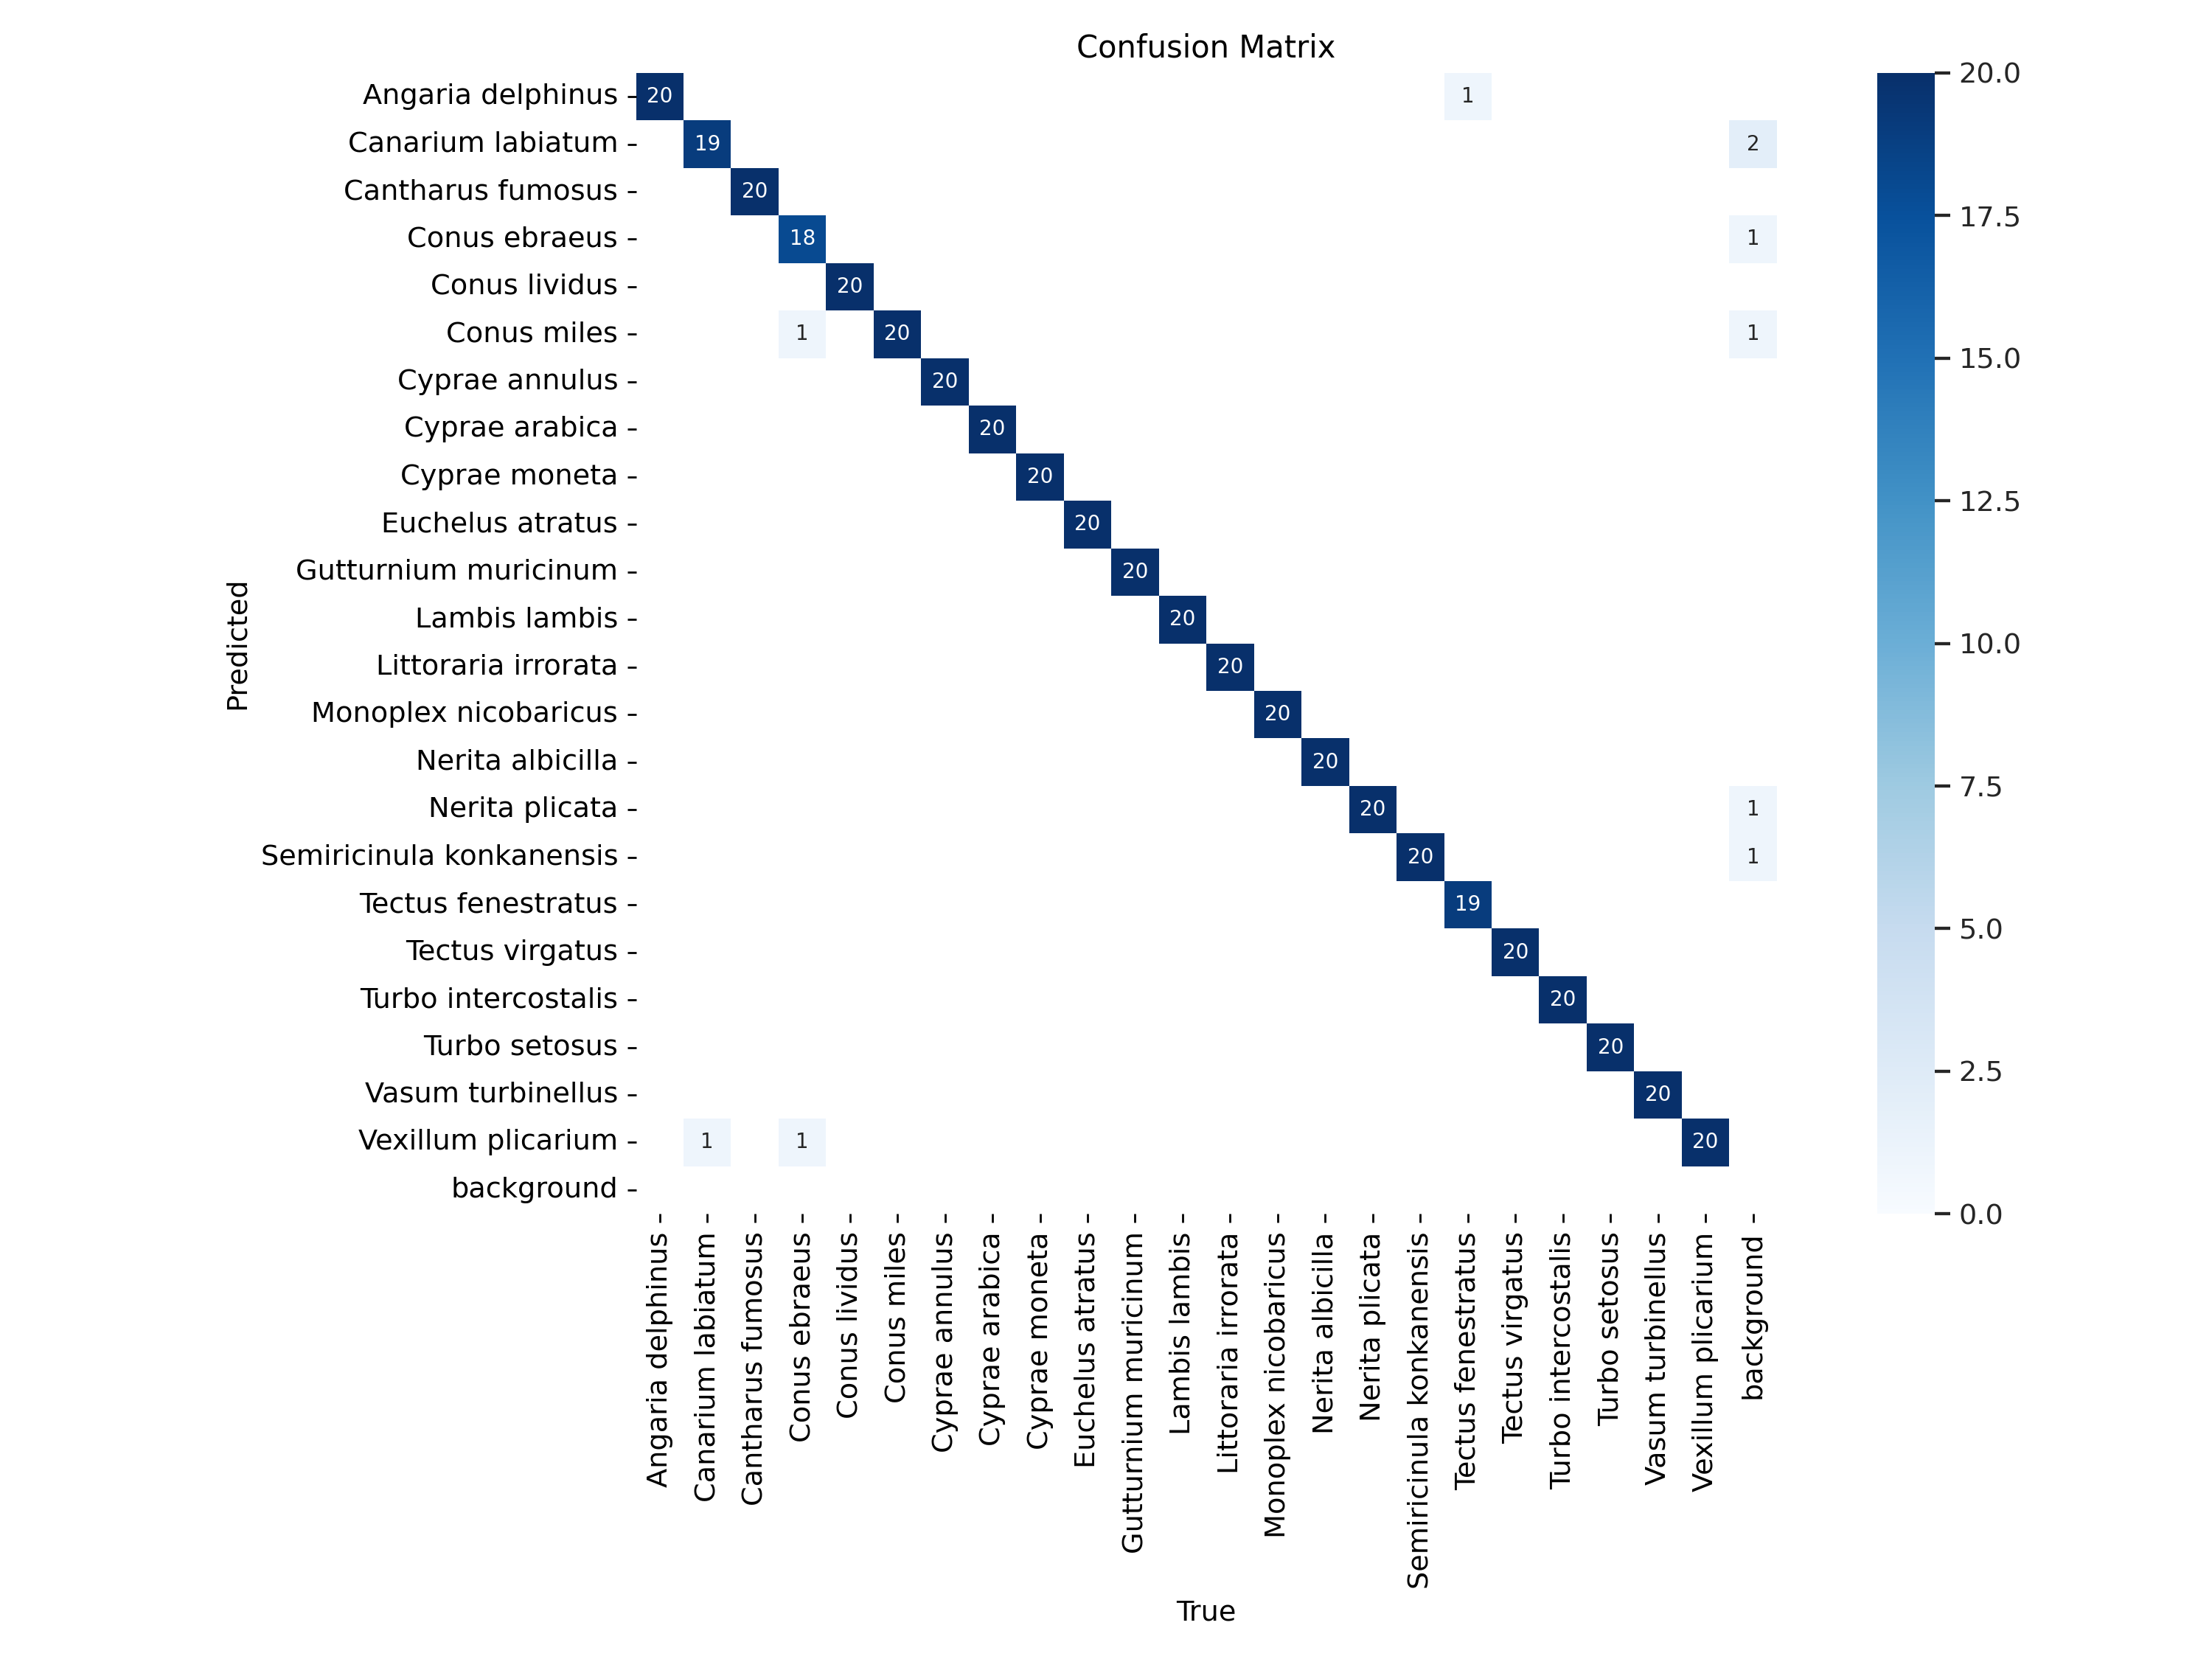

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/confusion_matrix.png', width=600)

/content


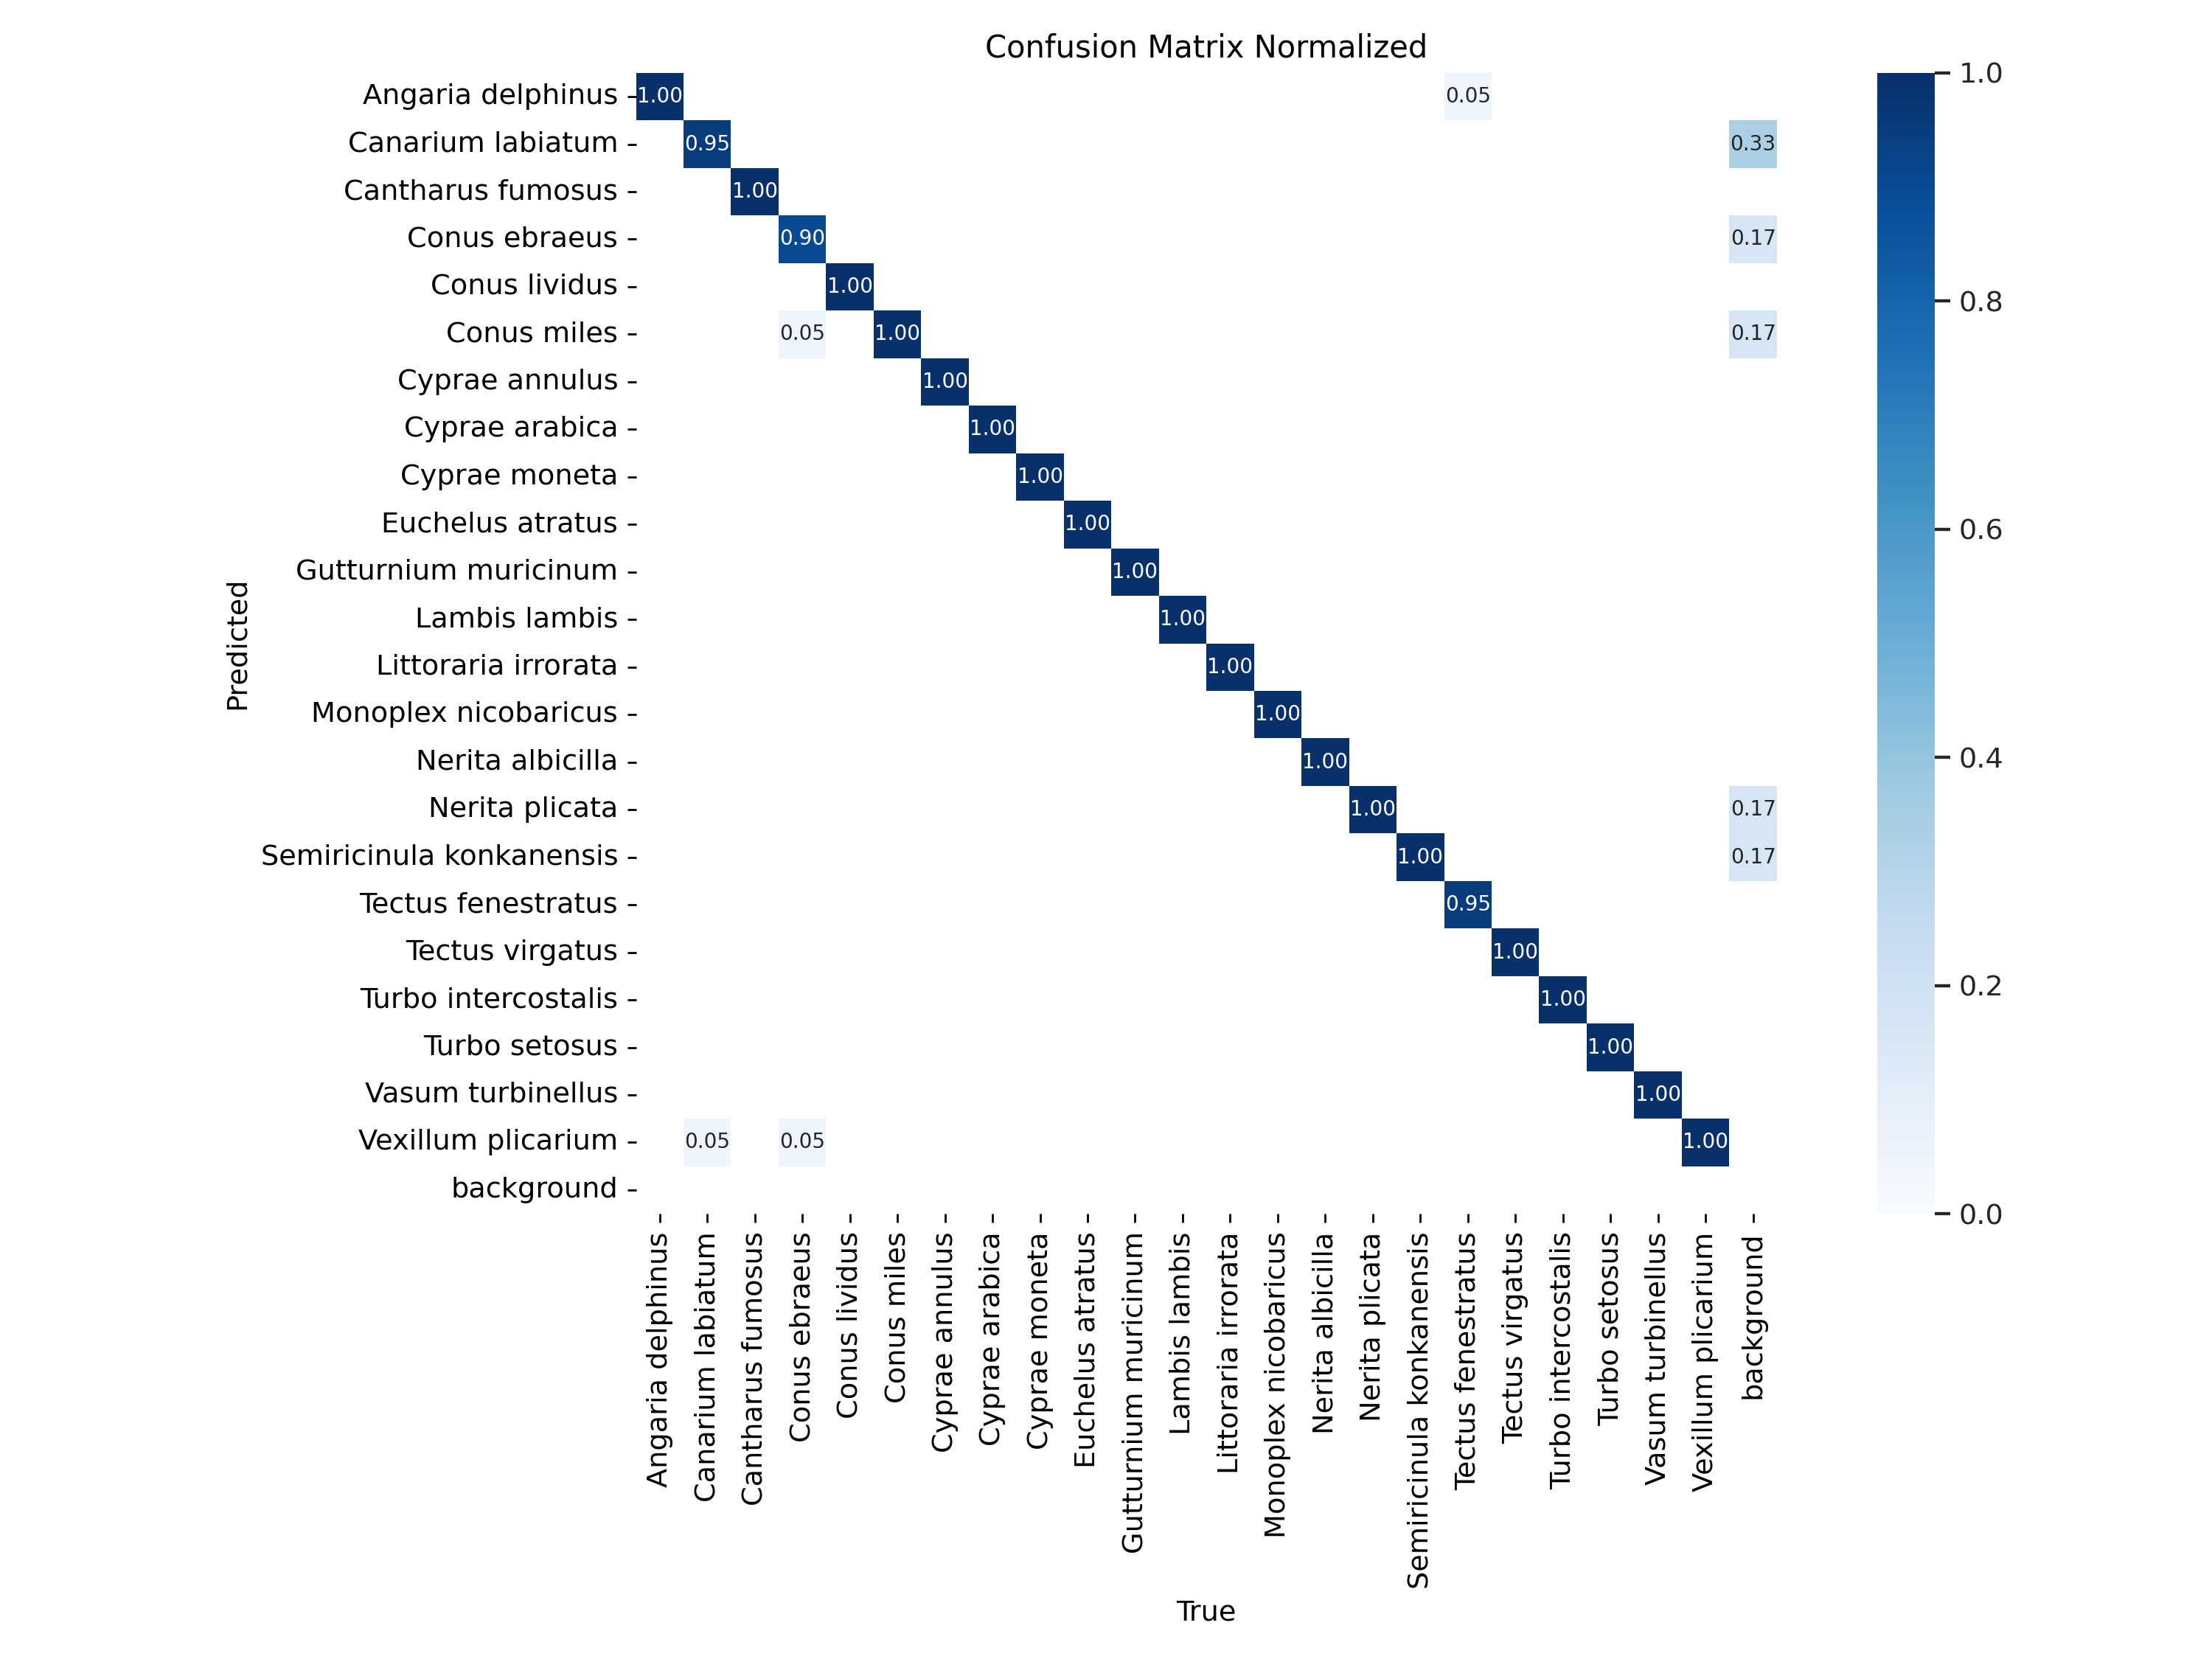

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/confusion_matrix_normalized.png', width=600)

# **BOX & MASK F1, P, PR, and R Curve**

**Box F1**

/content


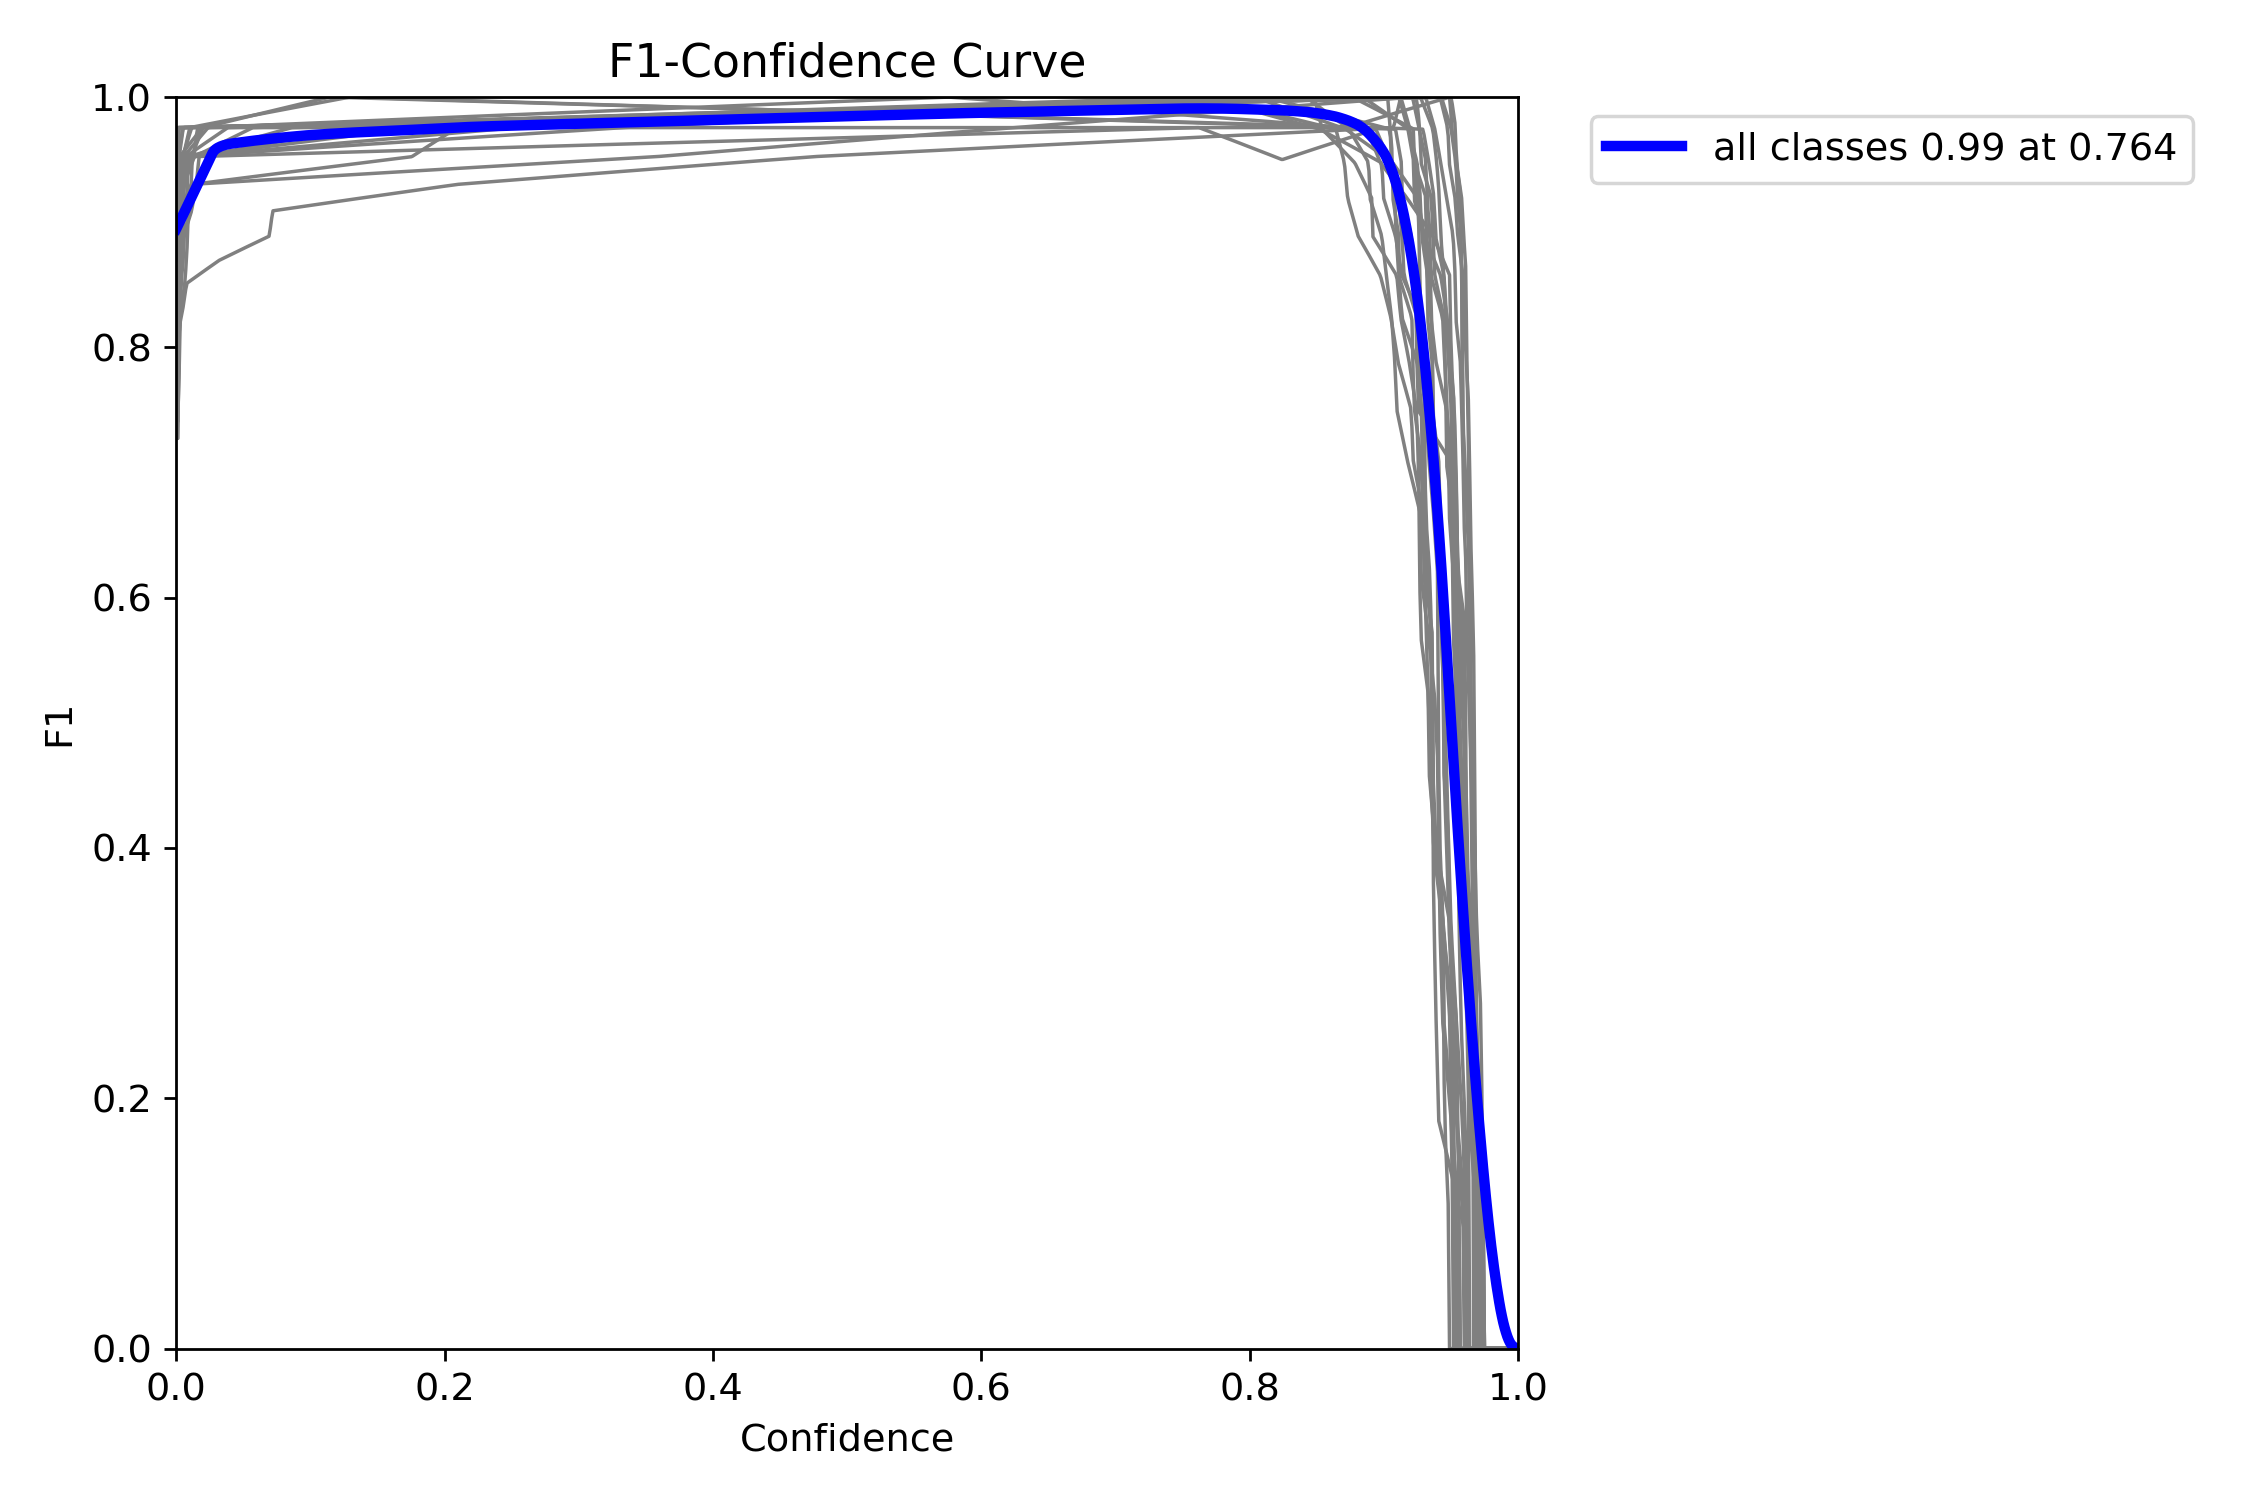

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/BoxF1_curve.png', width=600)

**Box P**

/content


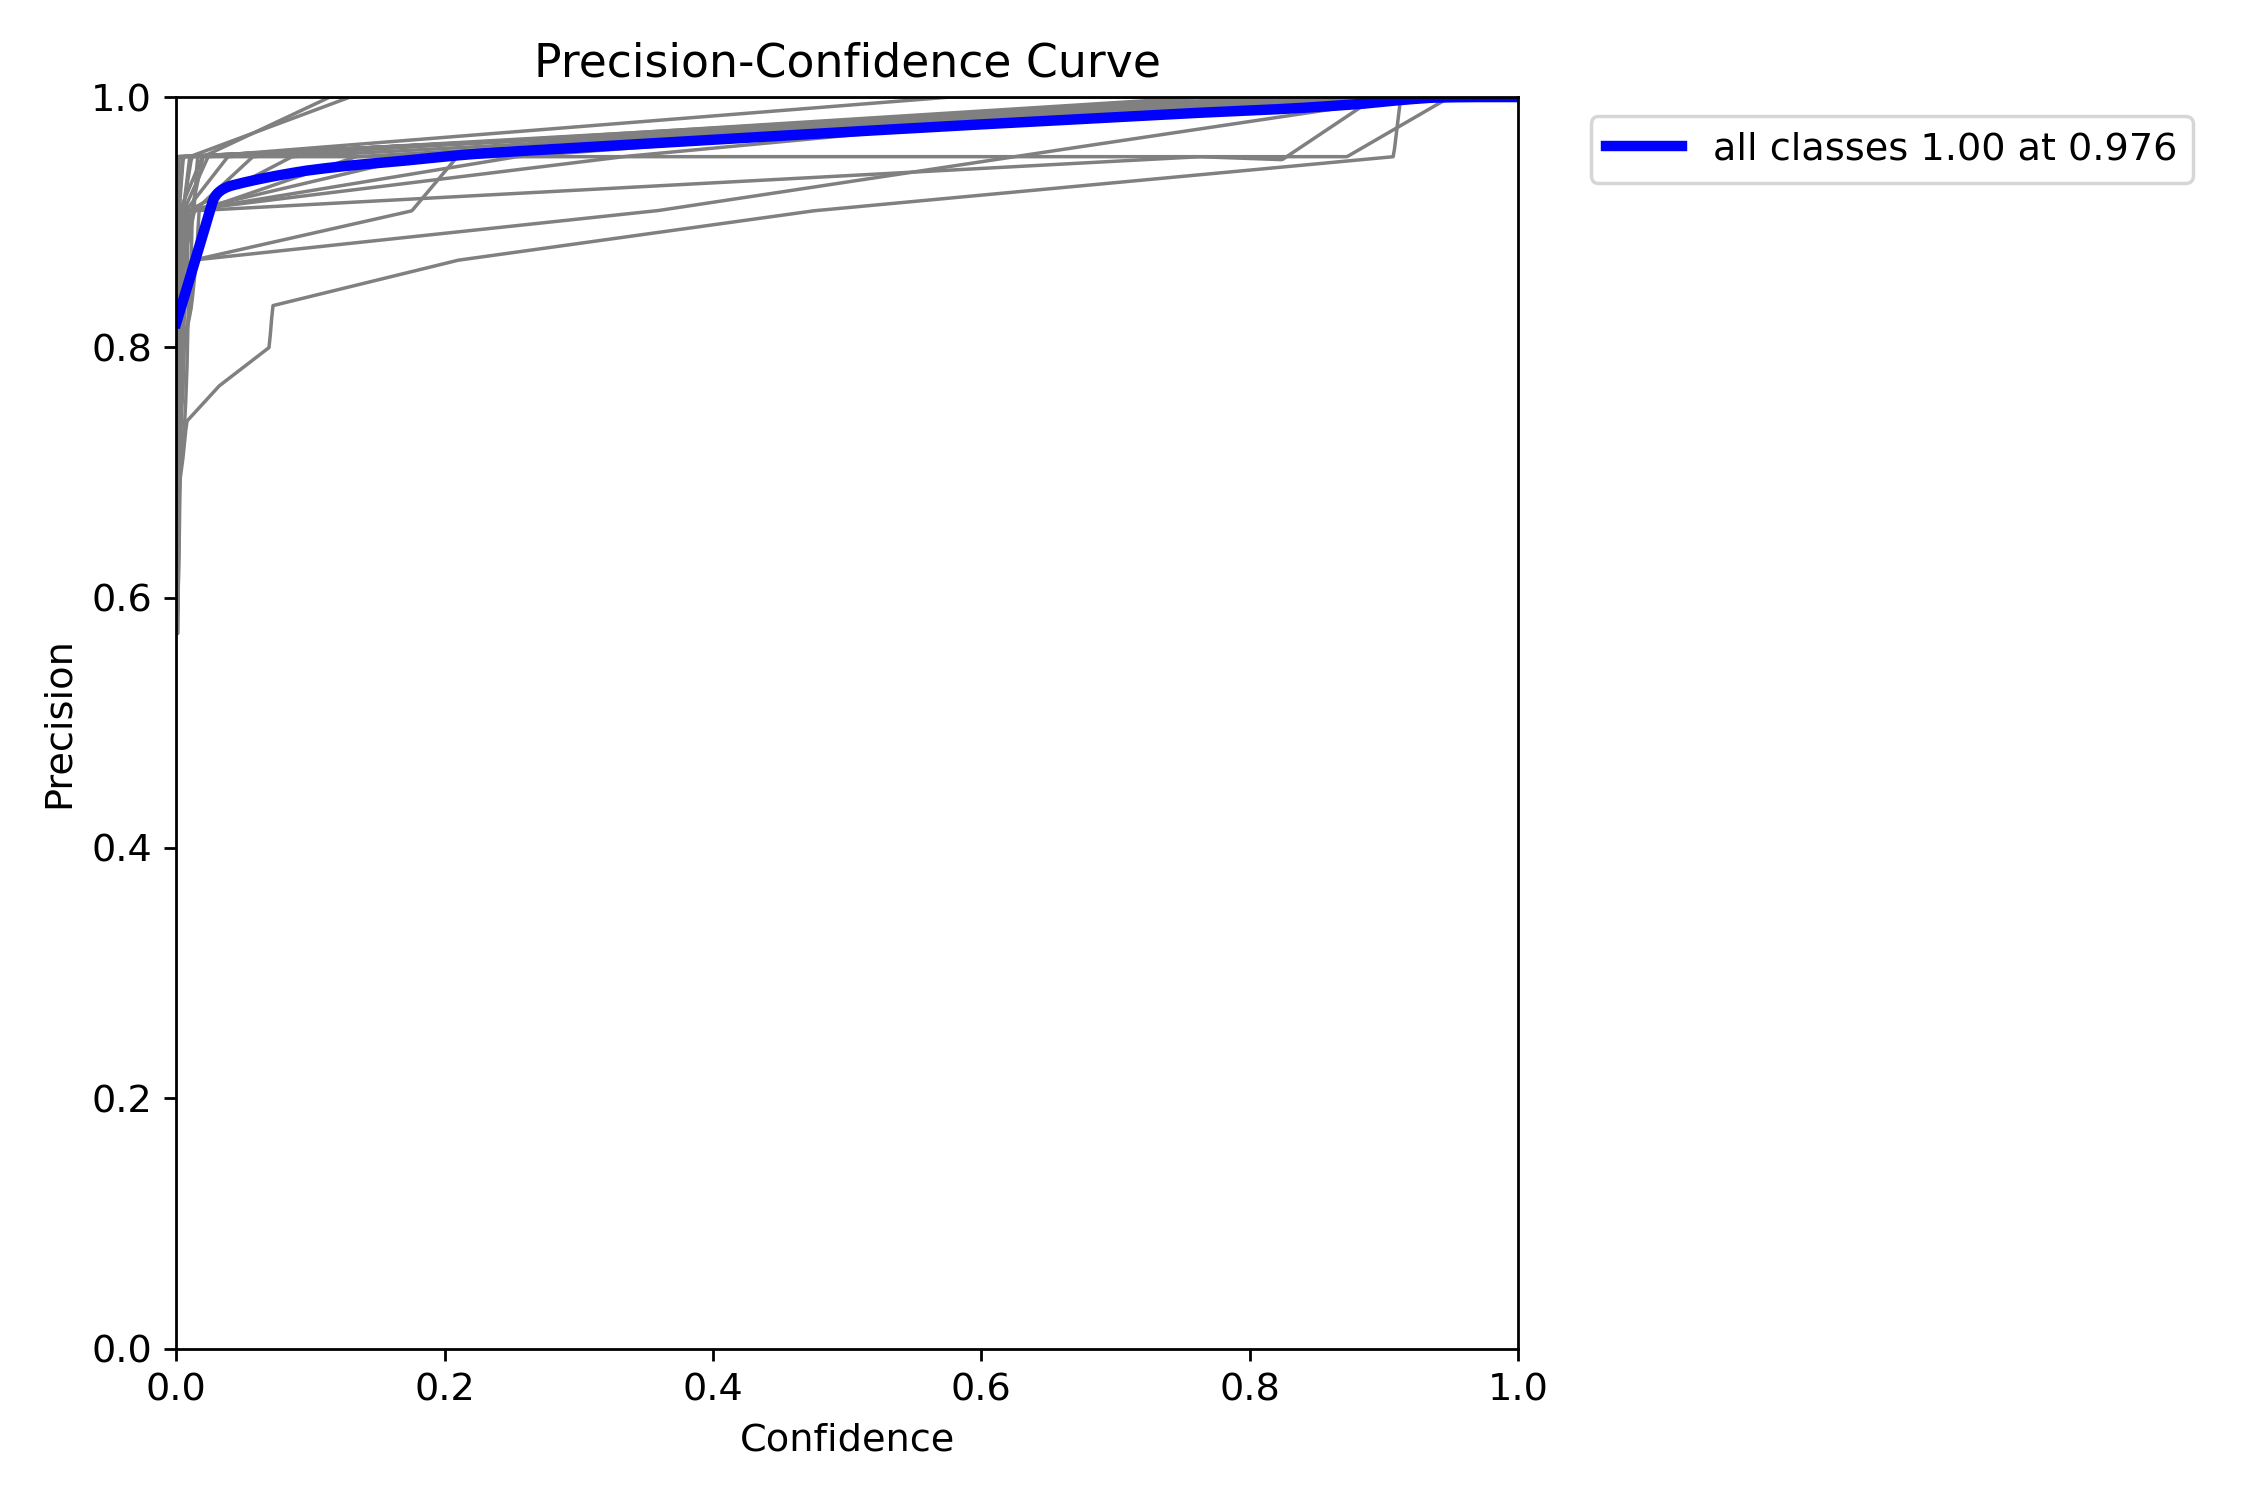

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/BoxP_curve.png', width=600)

**Box PR**

/content


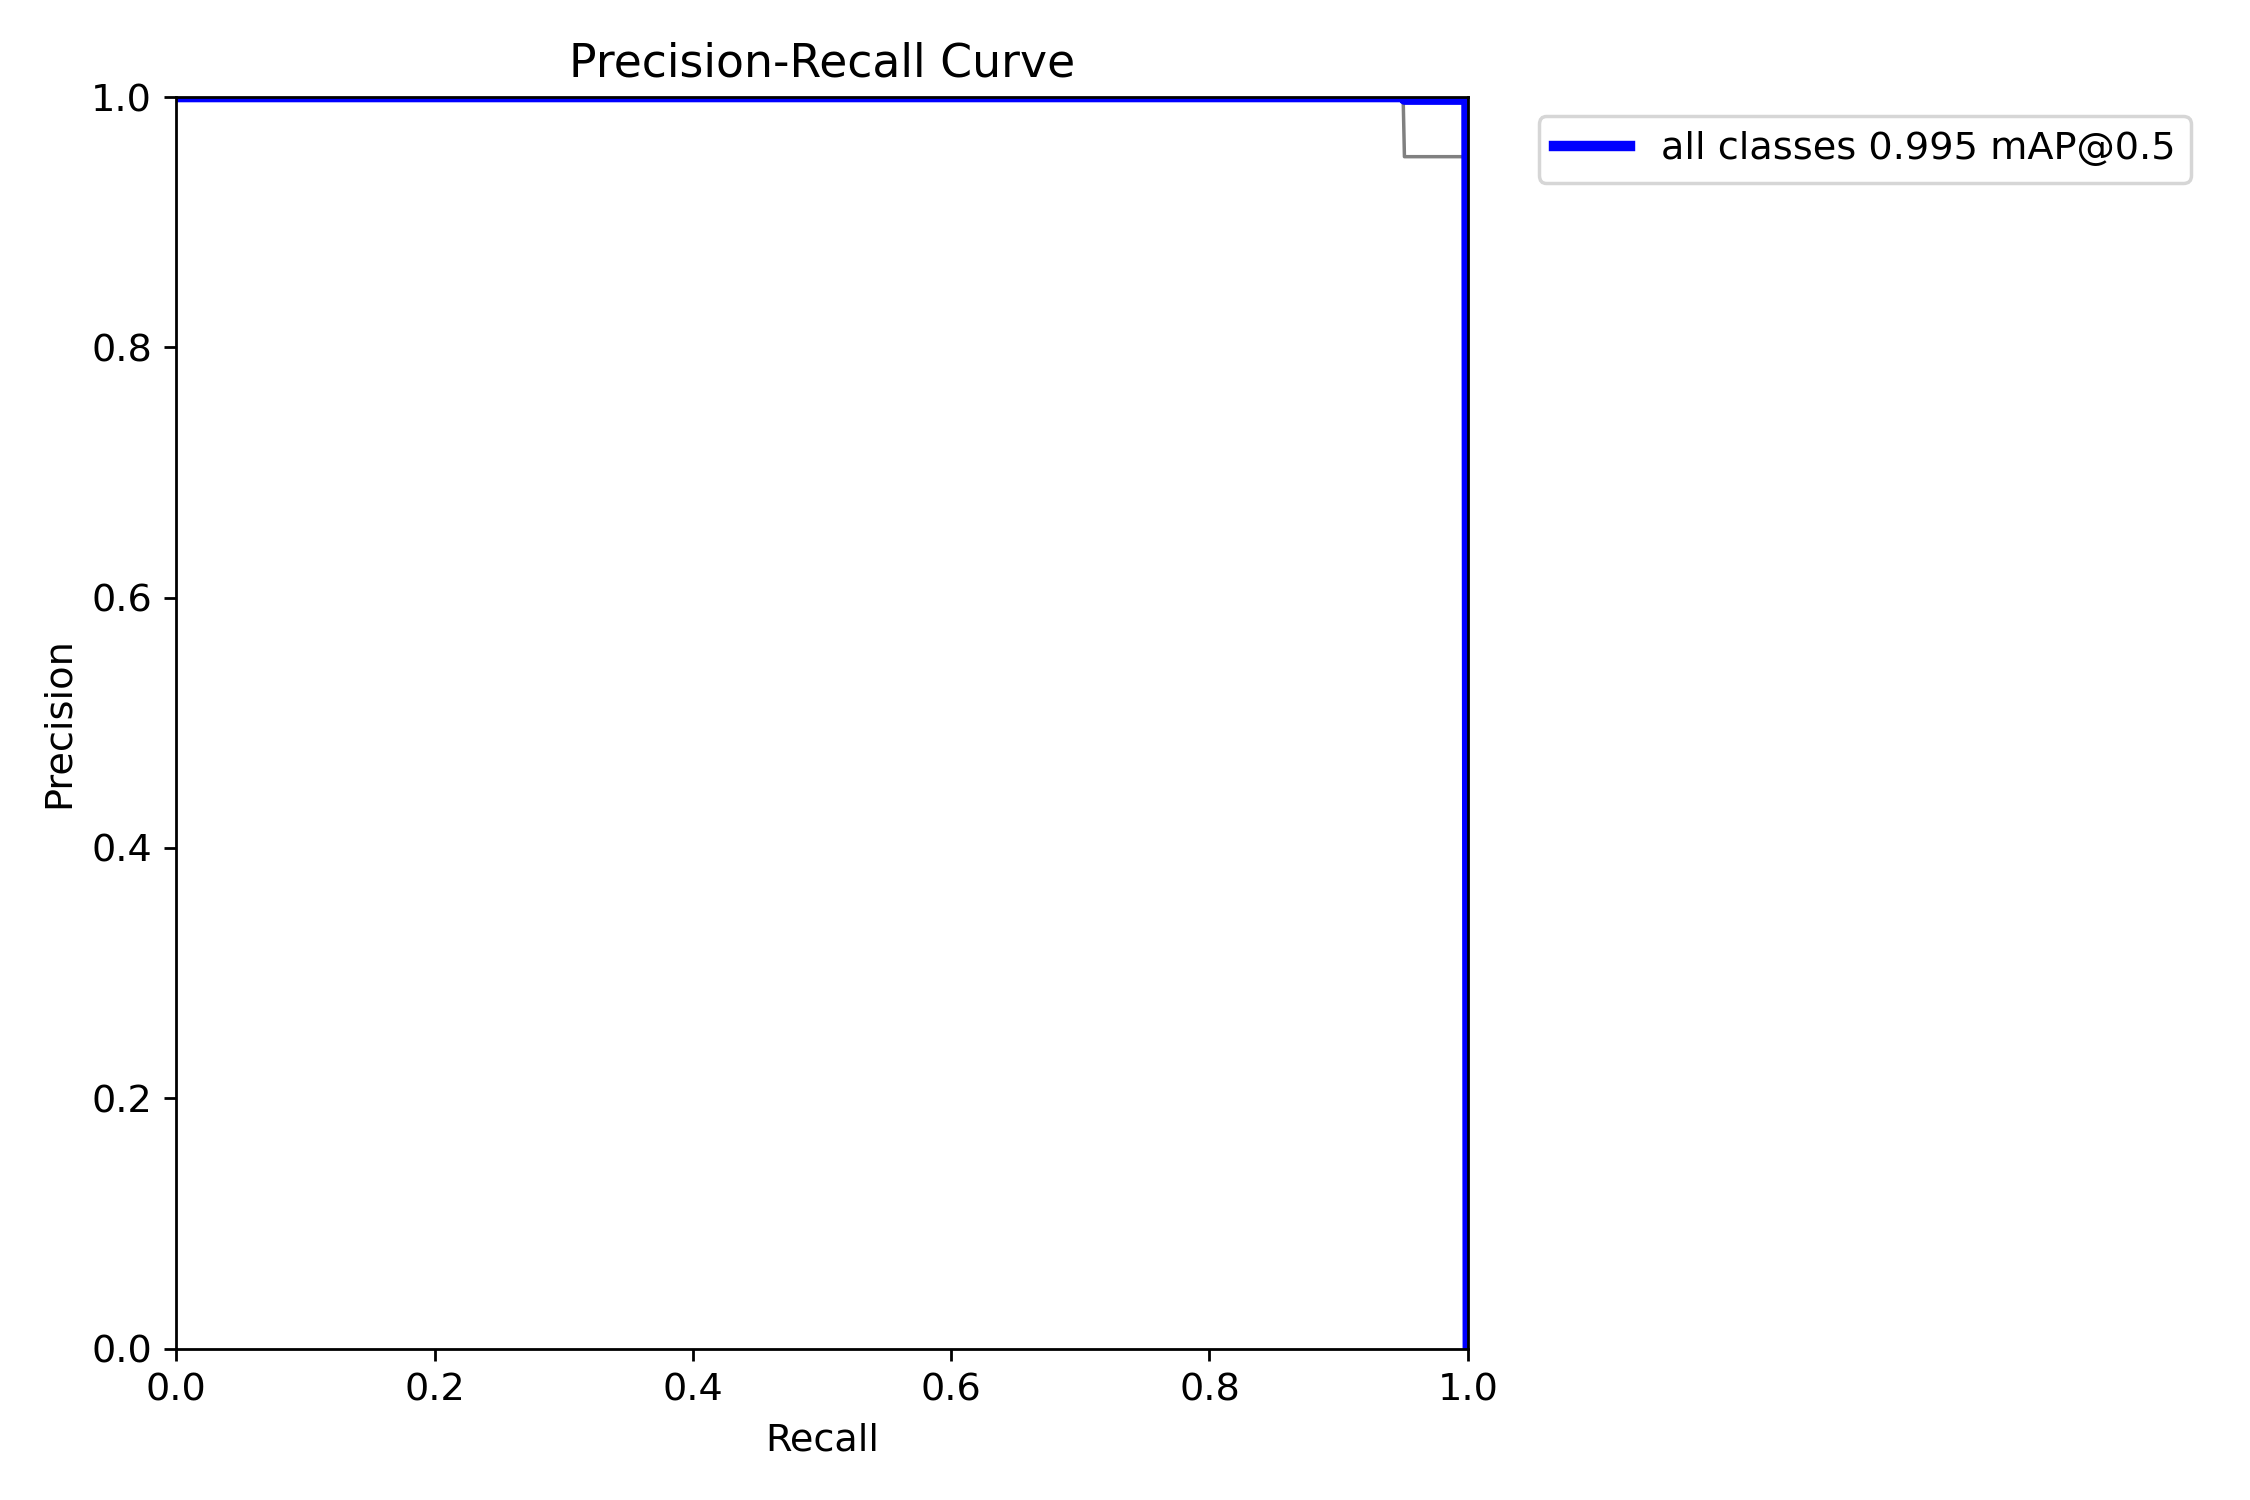

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/BoxPR_curve.png', width=600)

**Box R**

/content


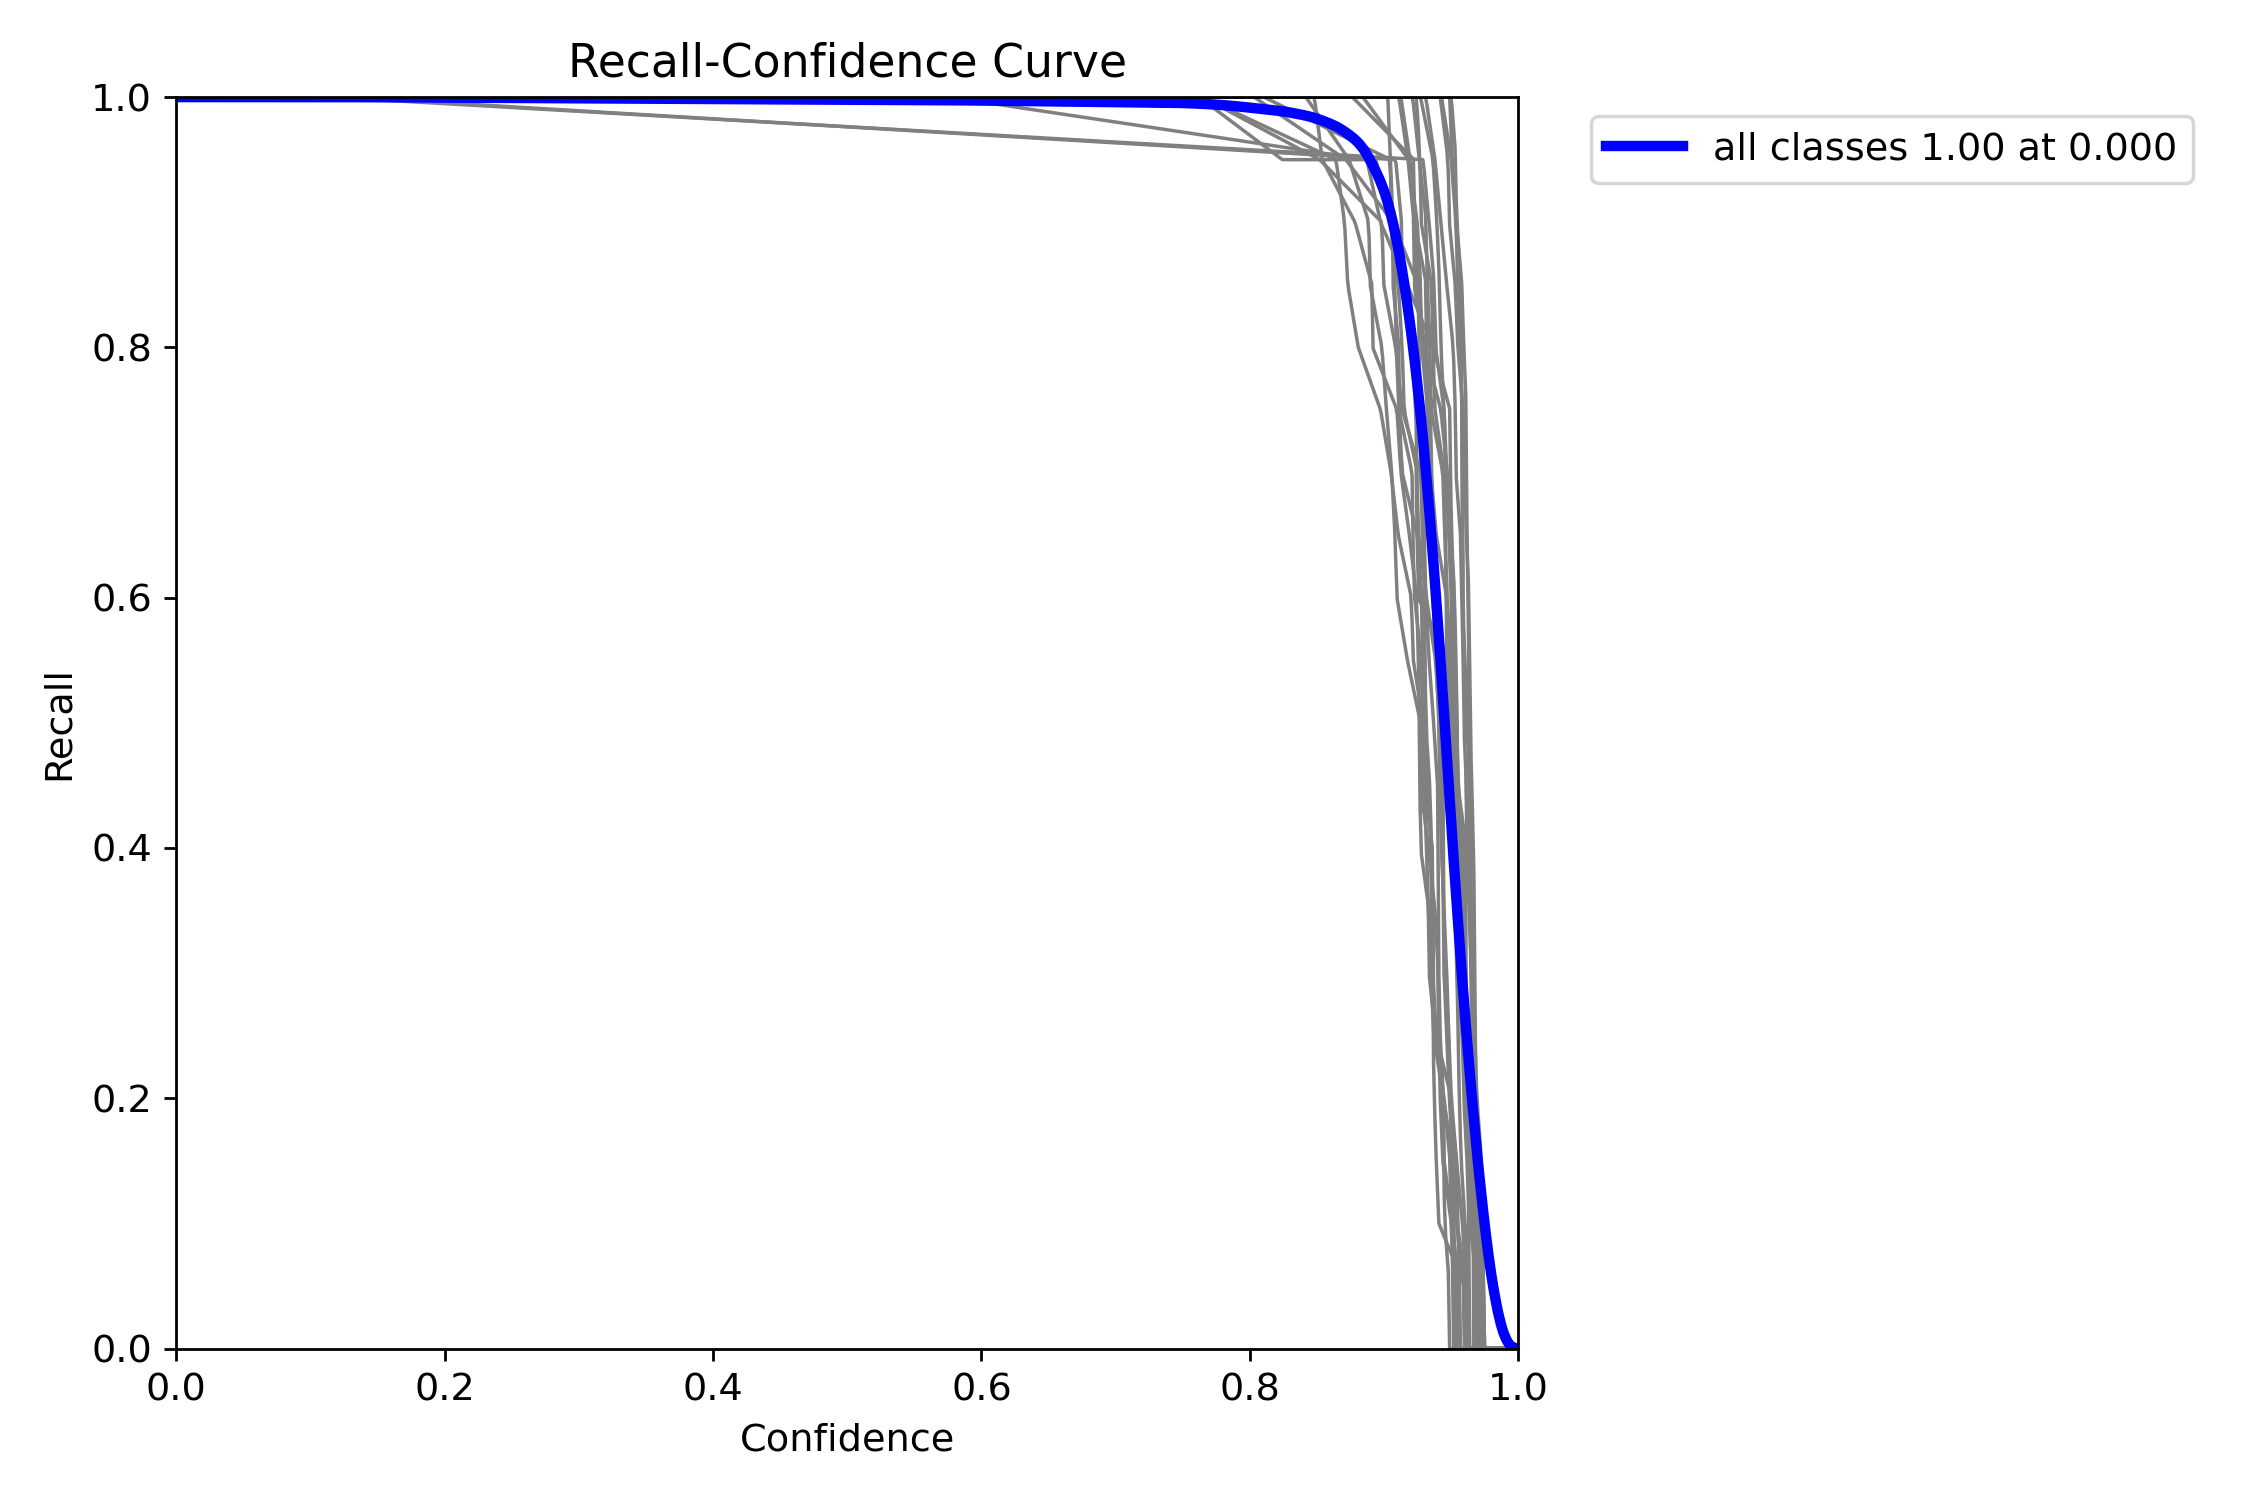

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/BoxR_curve.png', width=600)

**Mask F1**

/content


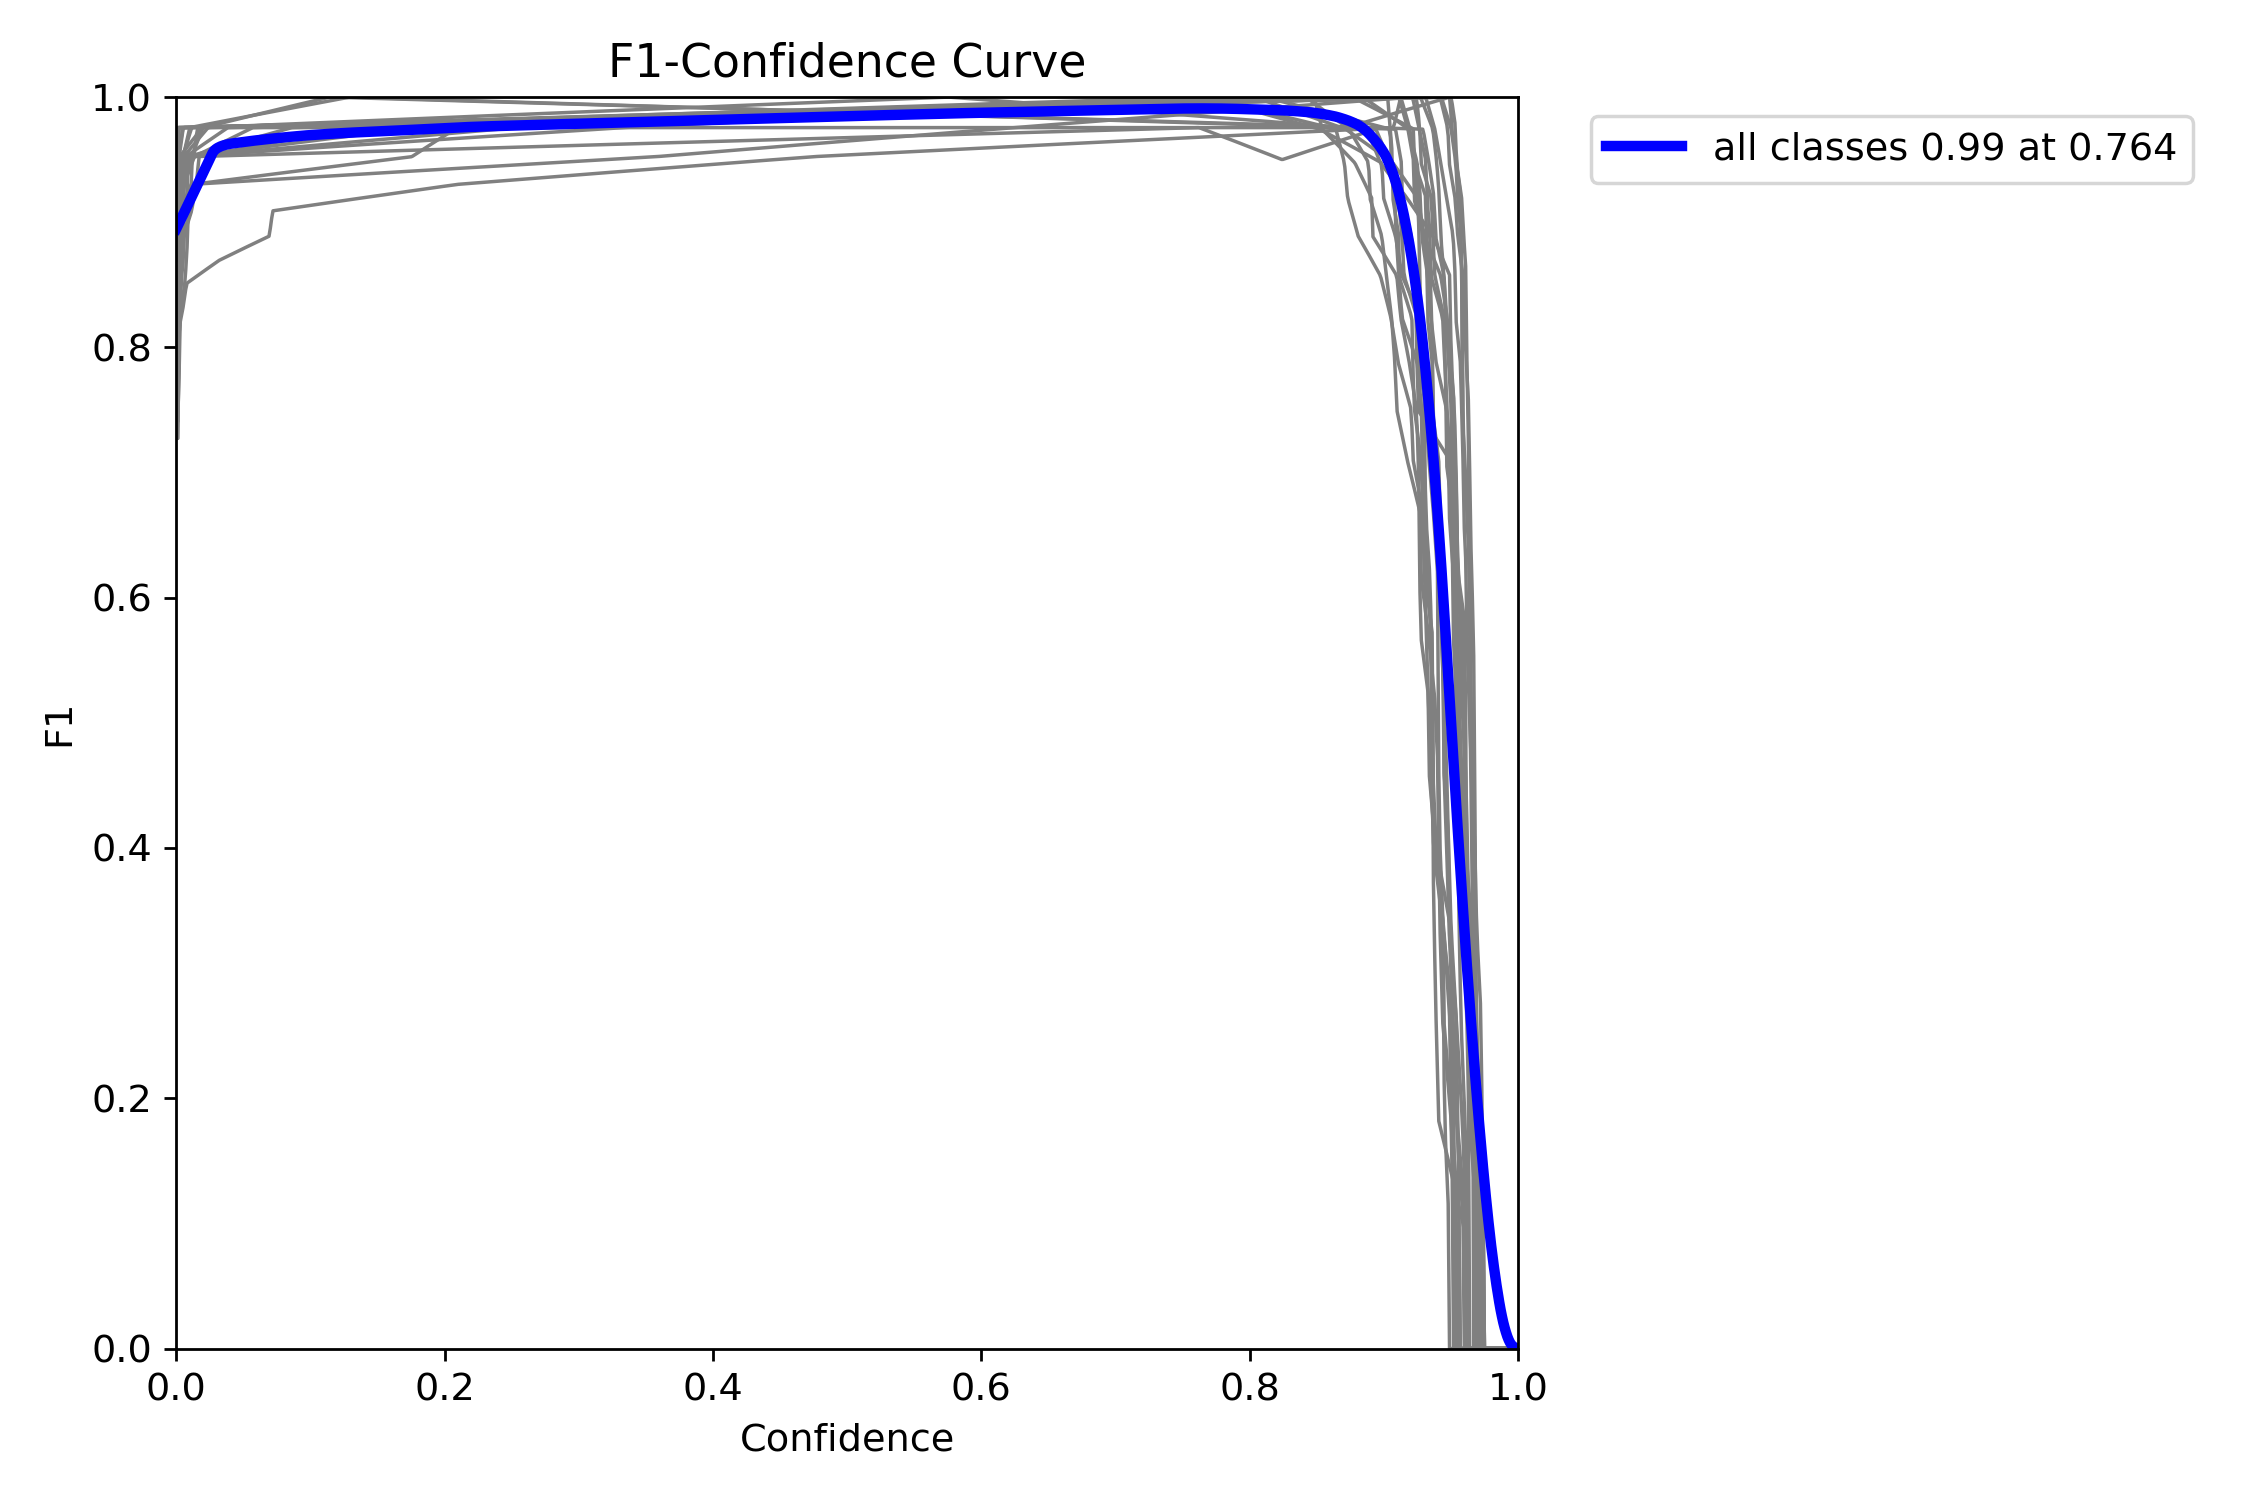

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/MaskF1_curve.png', width=600)

**Mask P**

/content


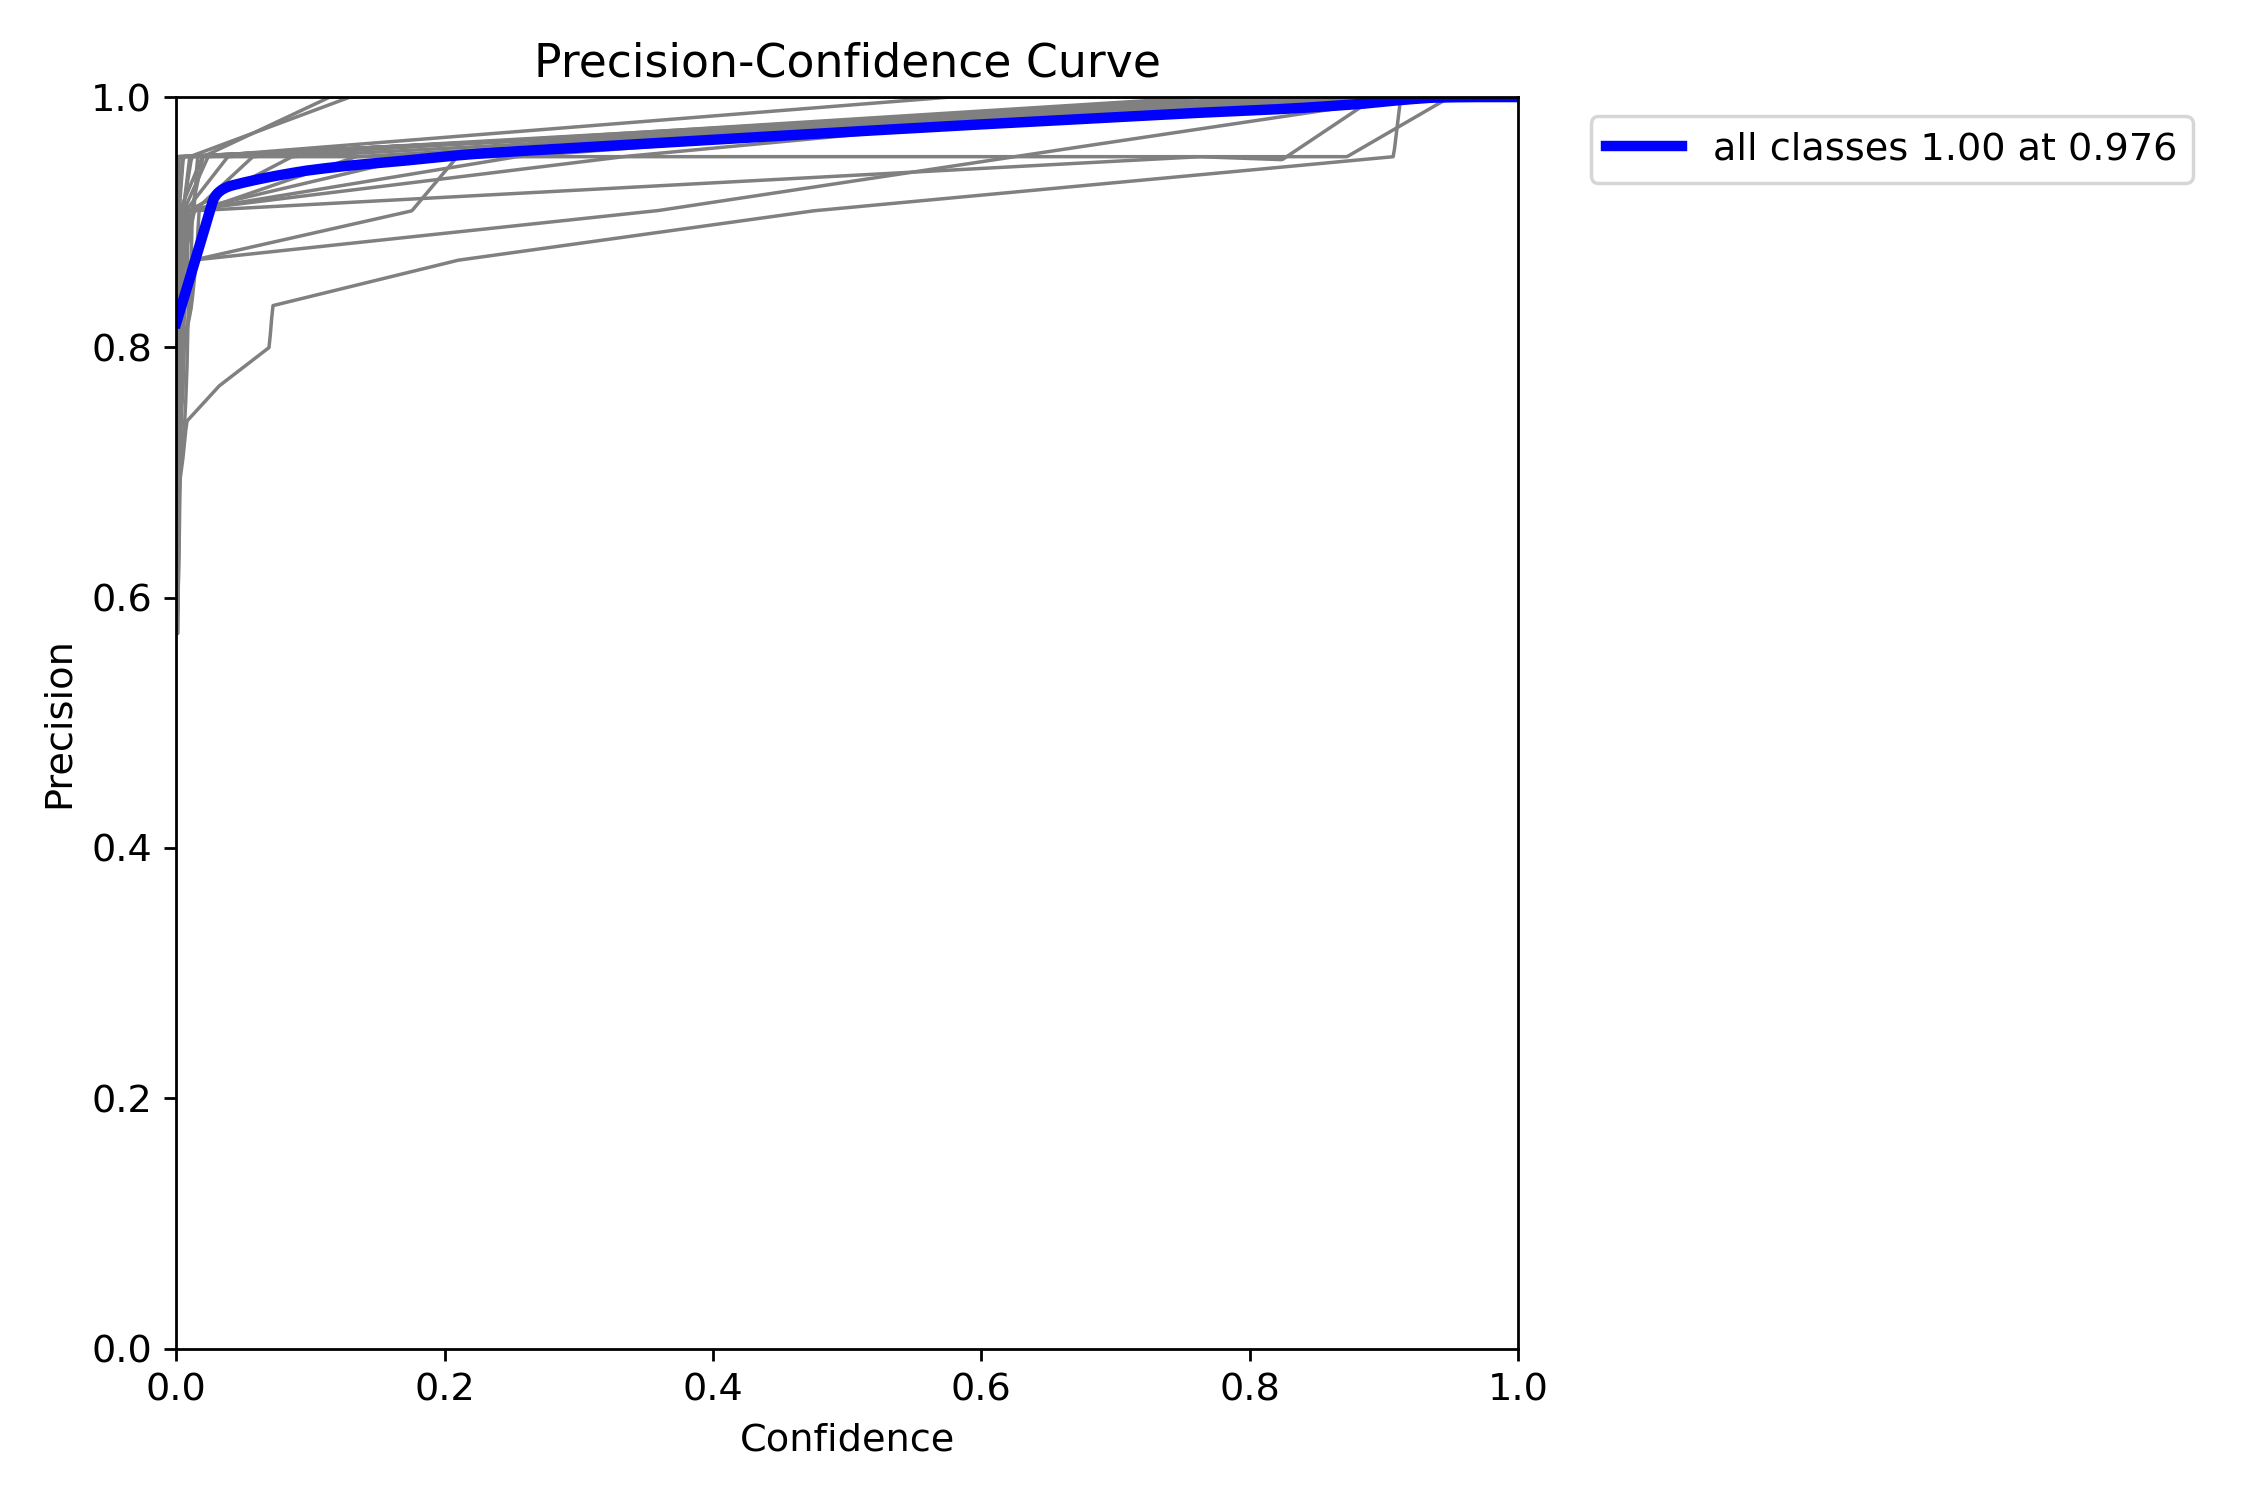

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/MaskP_curve.png', width=600)

**Mask PR**

/content


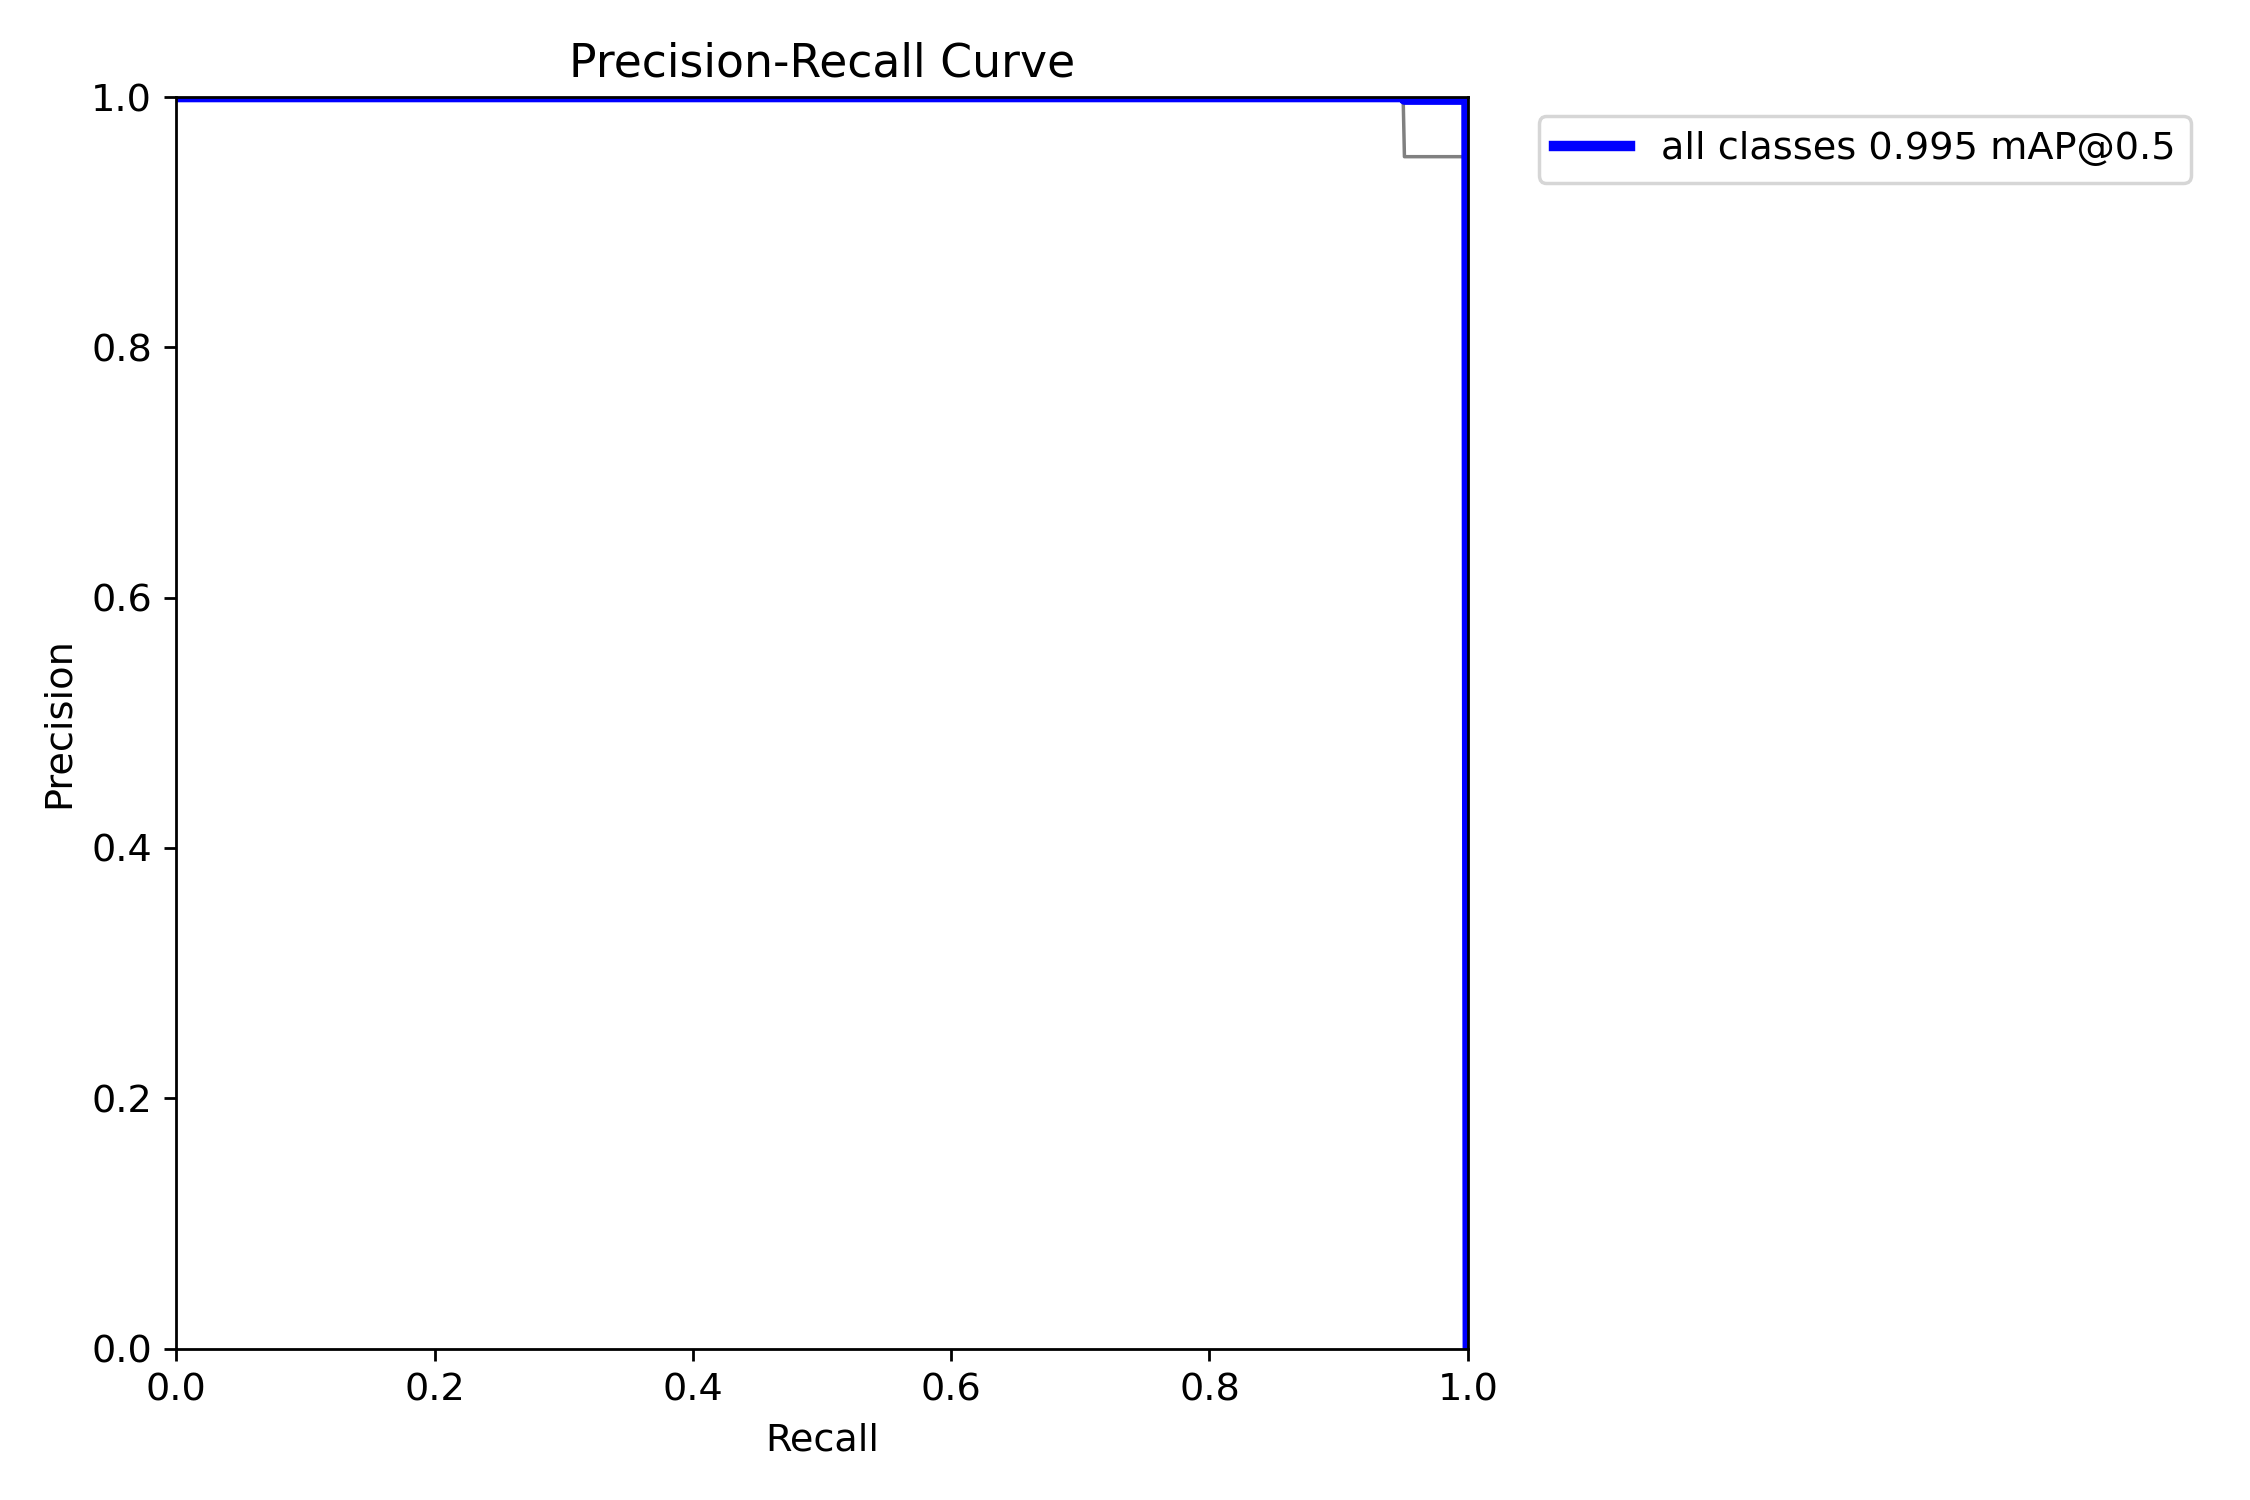

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/MaskPR_curve.png', width=600)

**Mask R**

/content


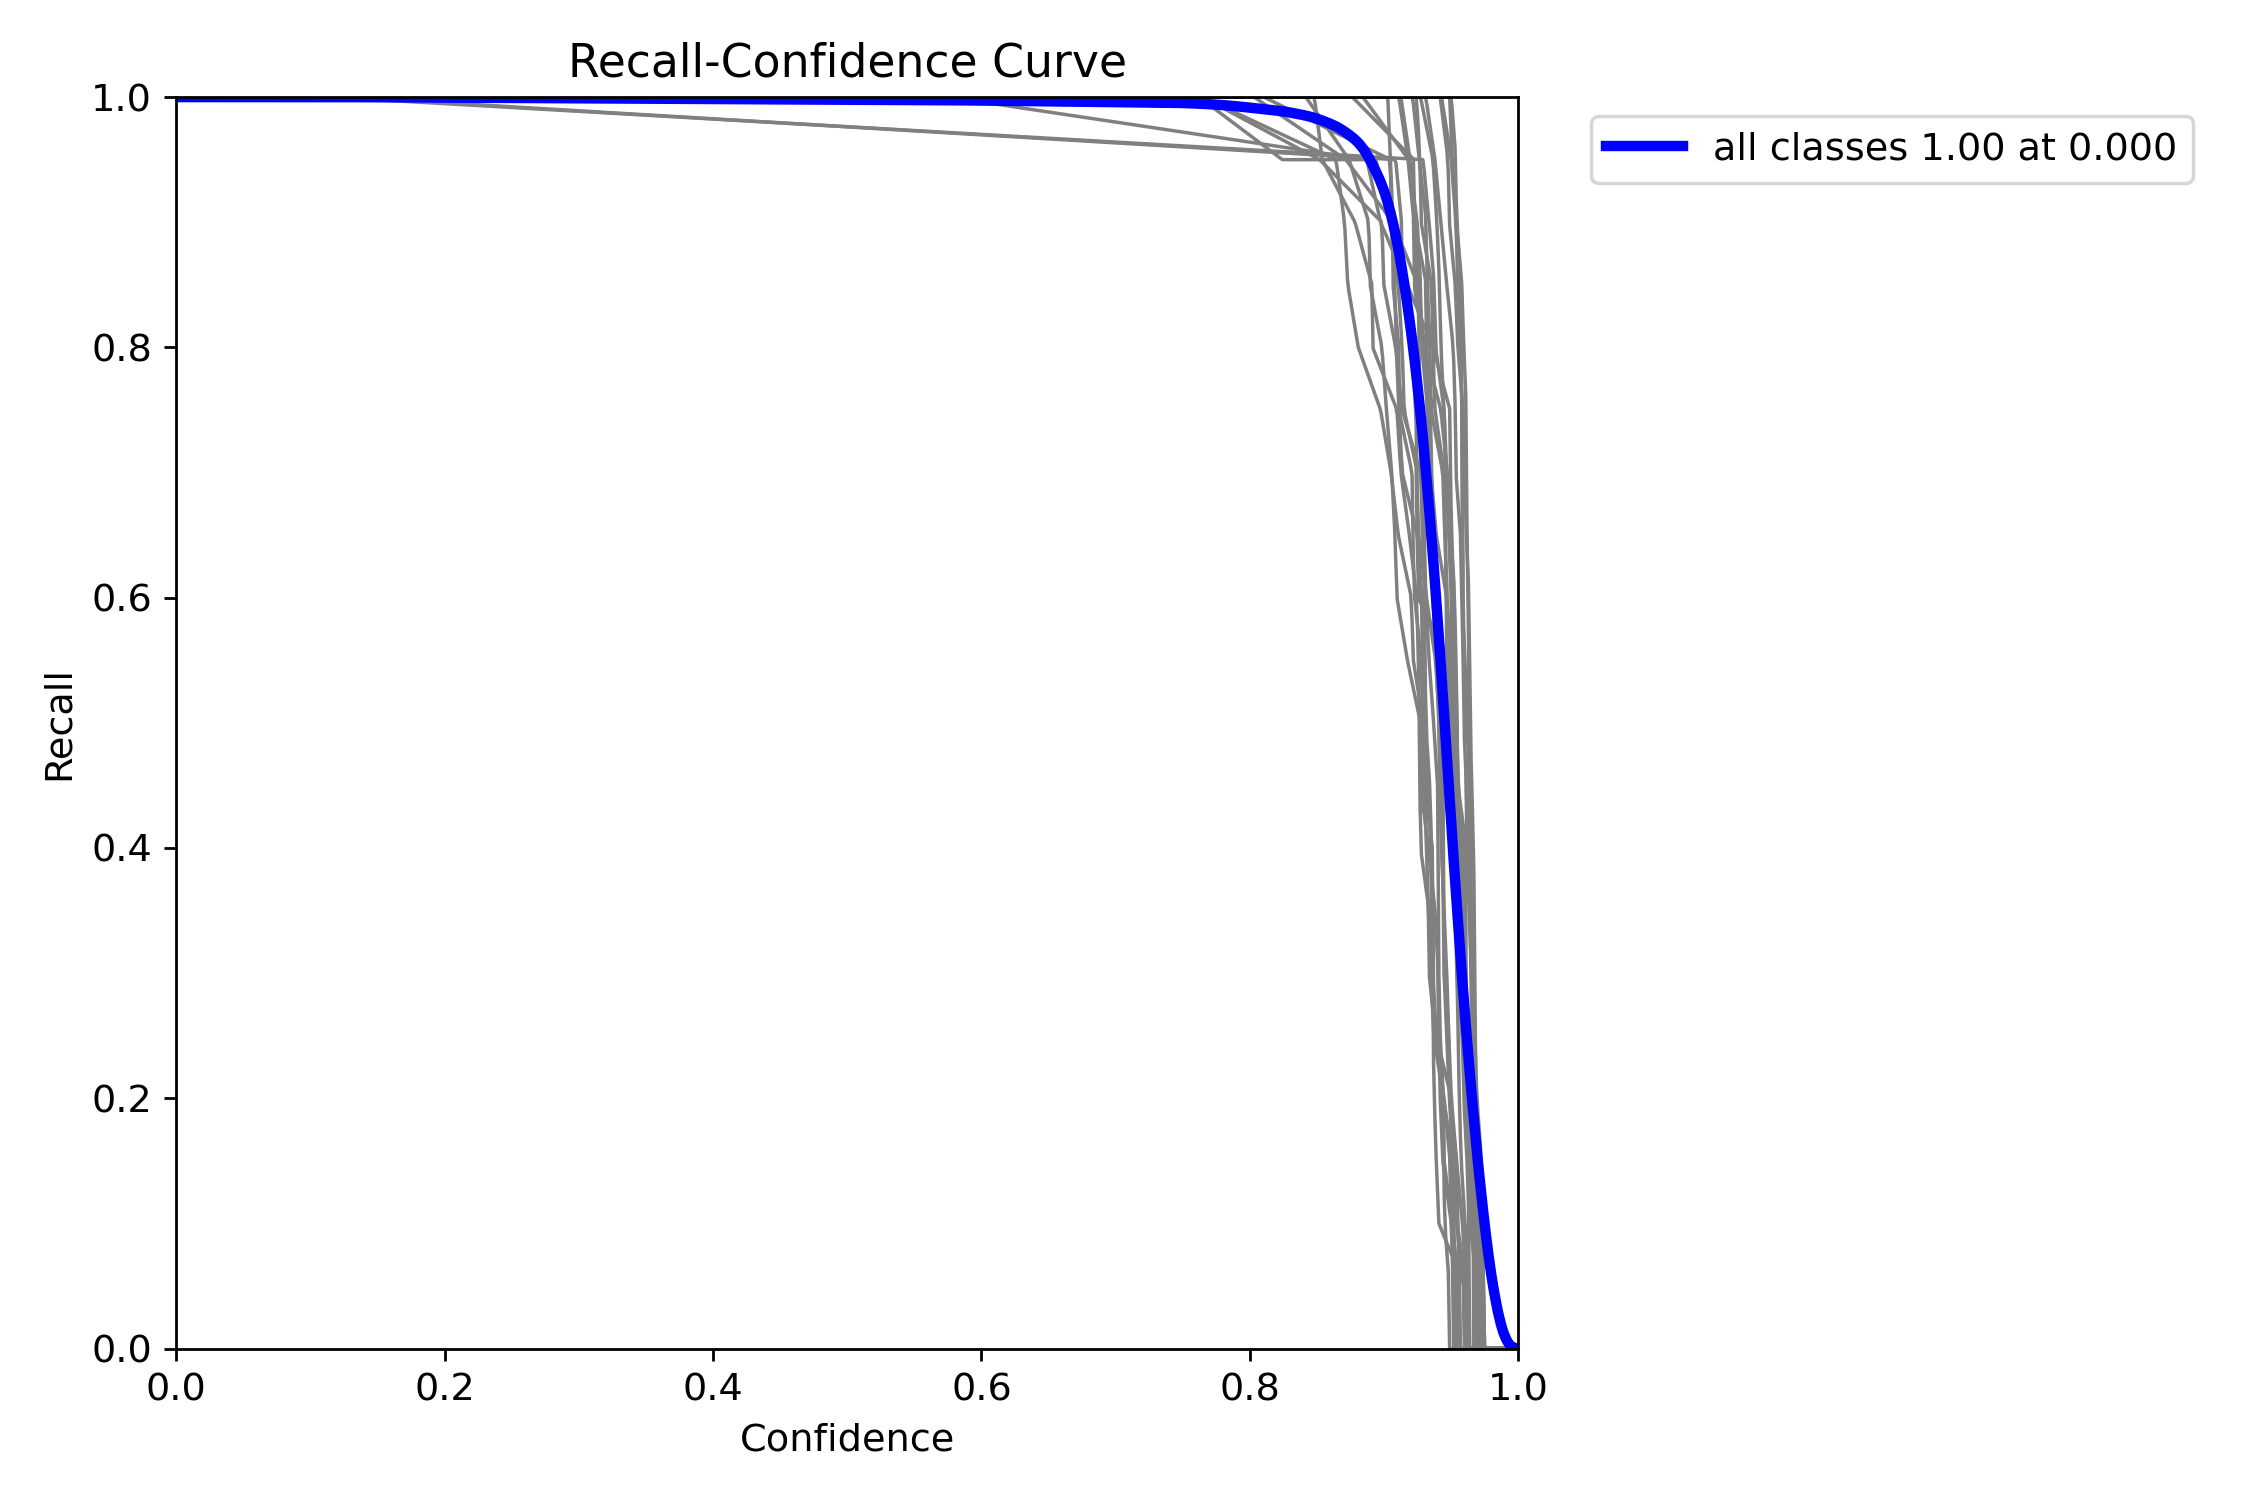

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/MaskR_curve.png', width=600)

# **Labels**

/content


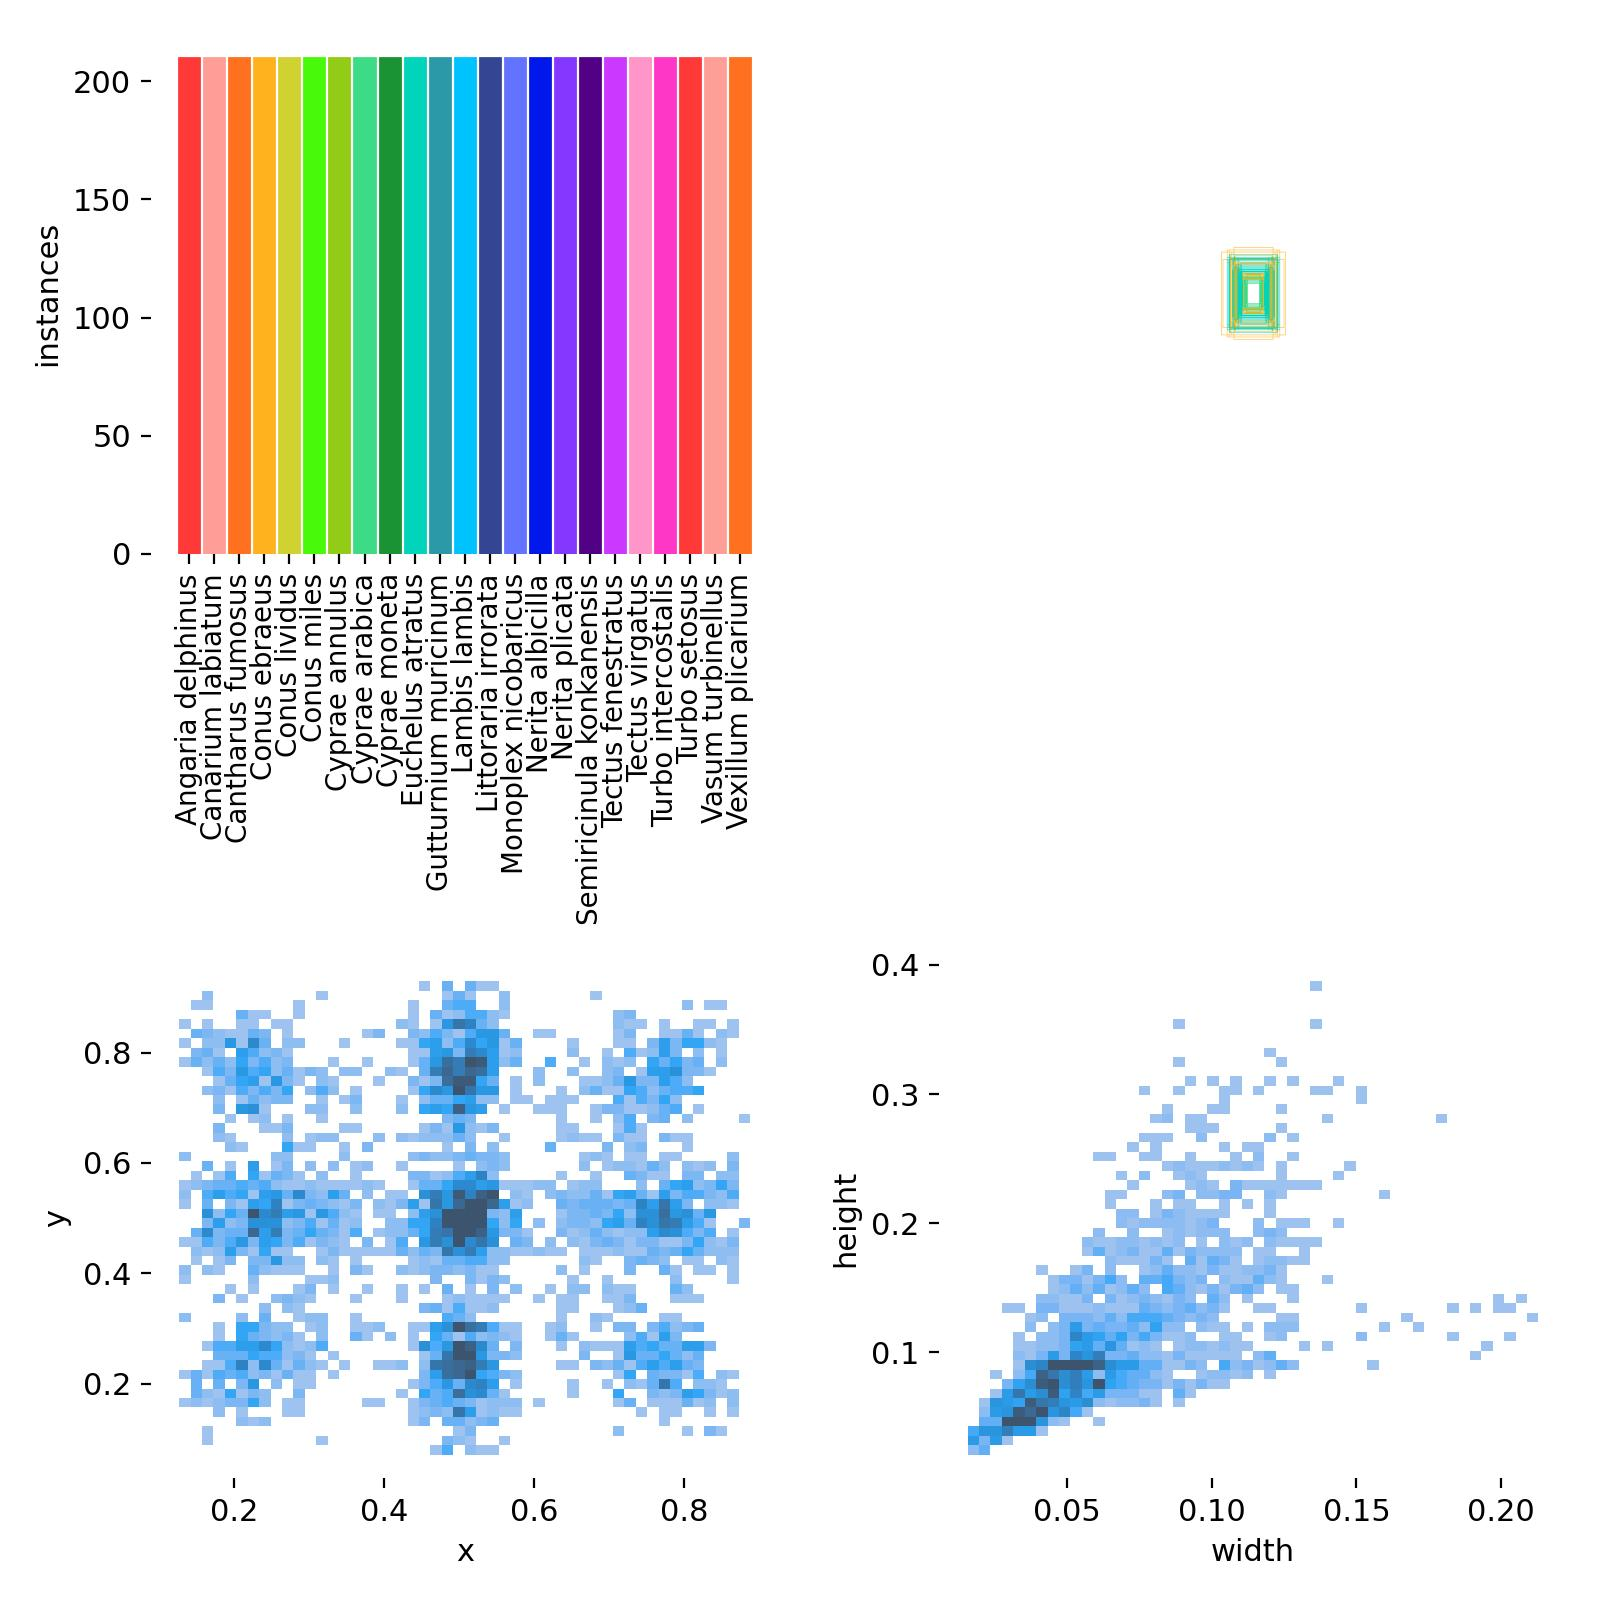

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/labels.jpg', width=600)

**Labels Correlogram**

/content


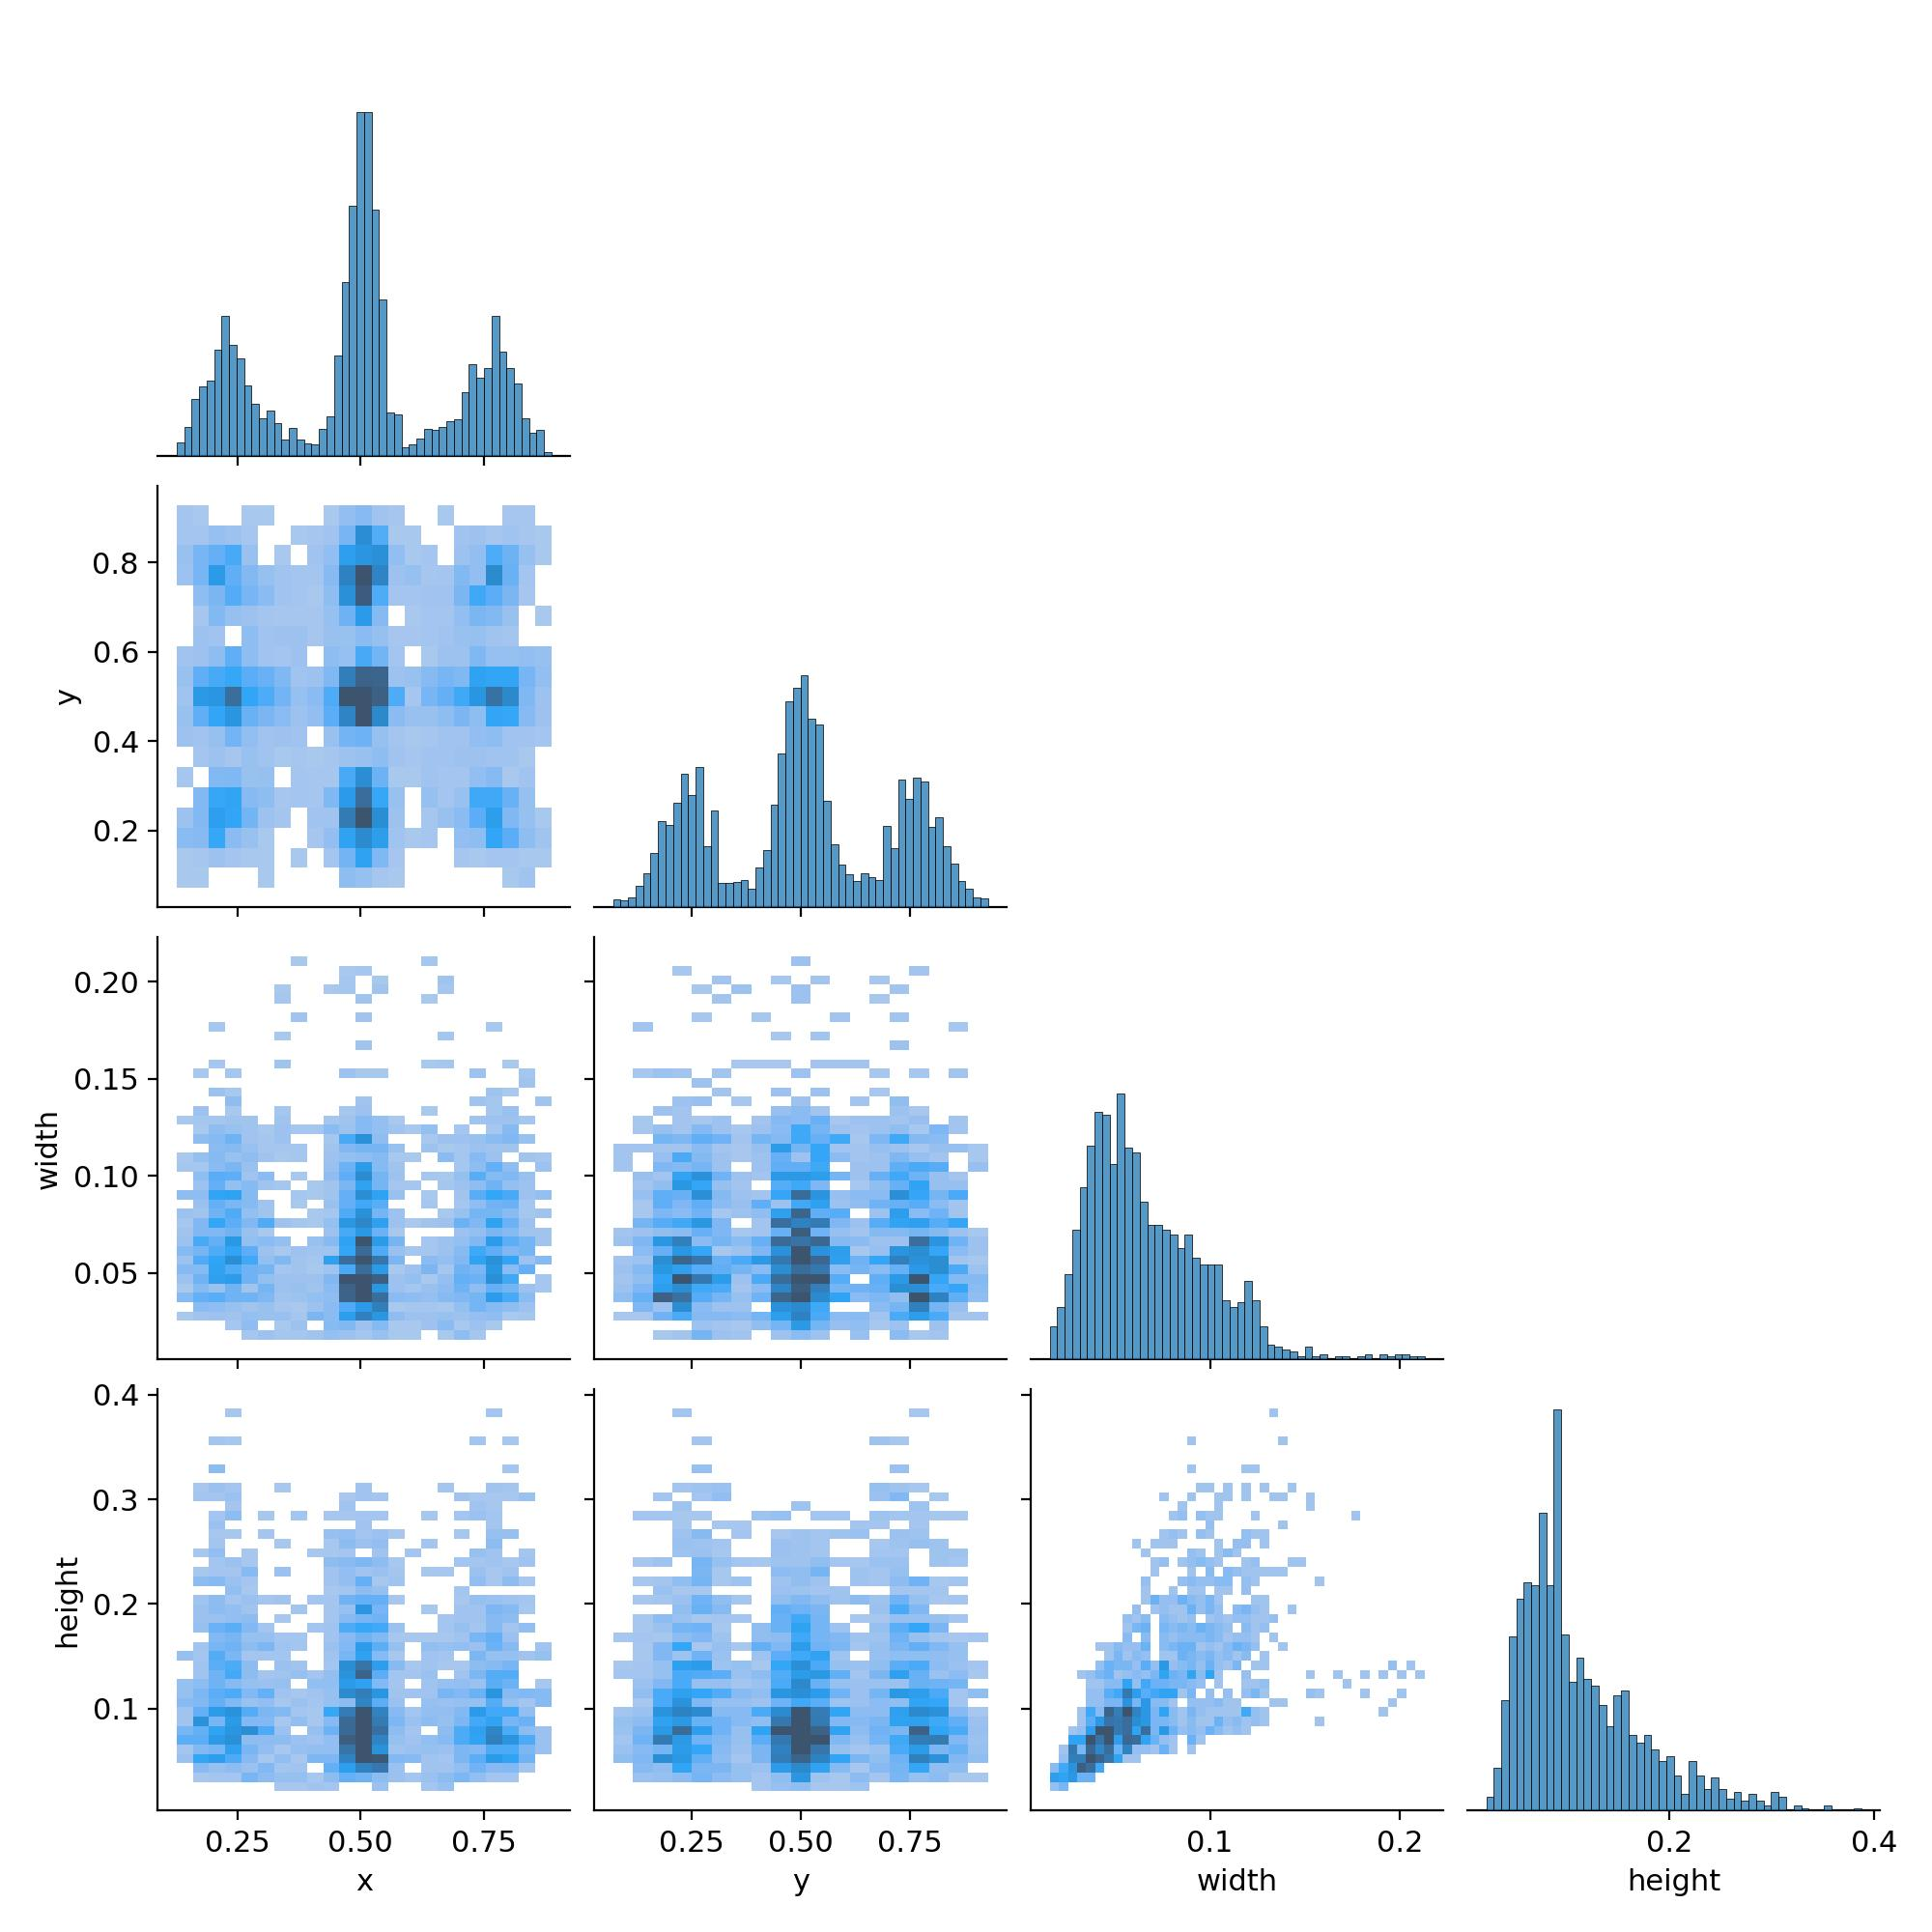

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/labels_correlogram.jpg', width=600)

# **Results**

/content


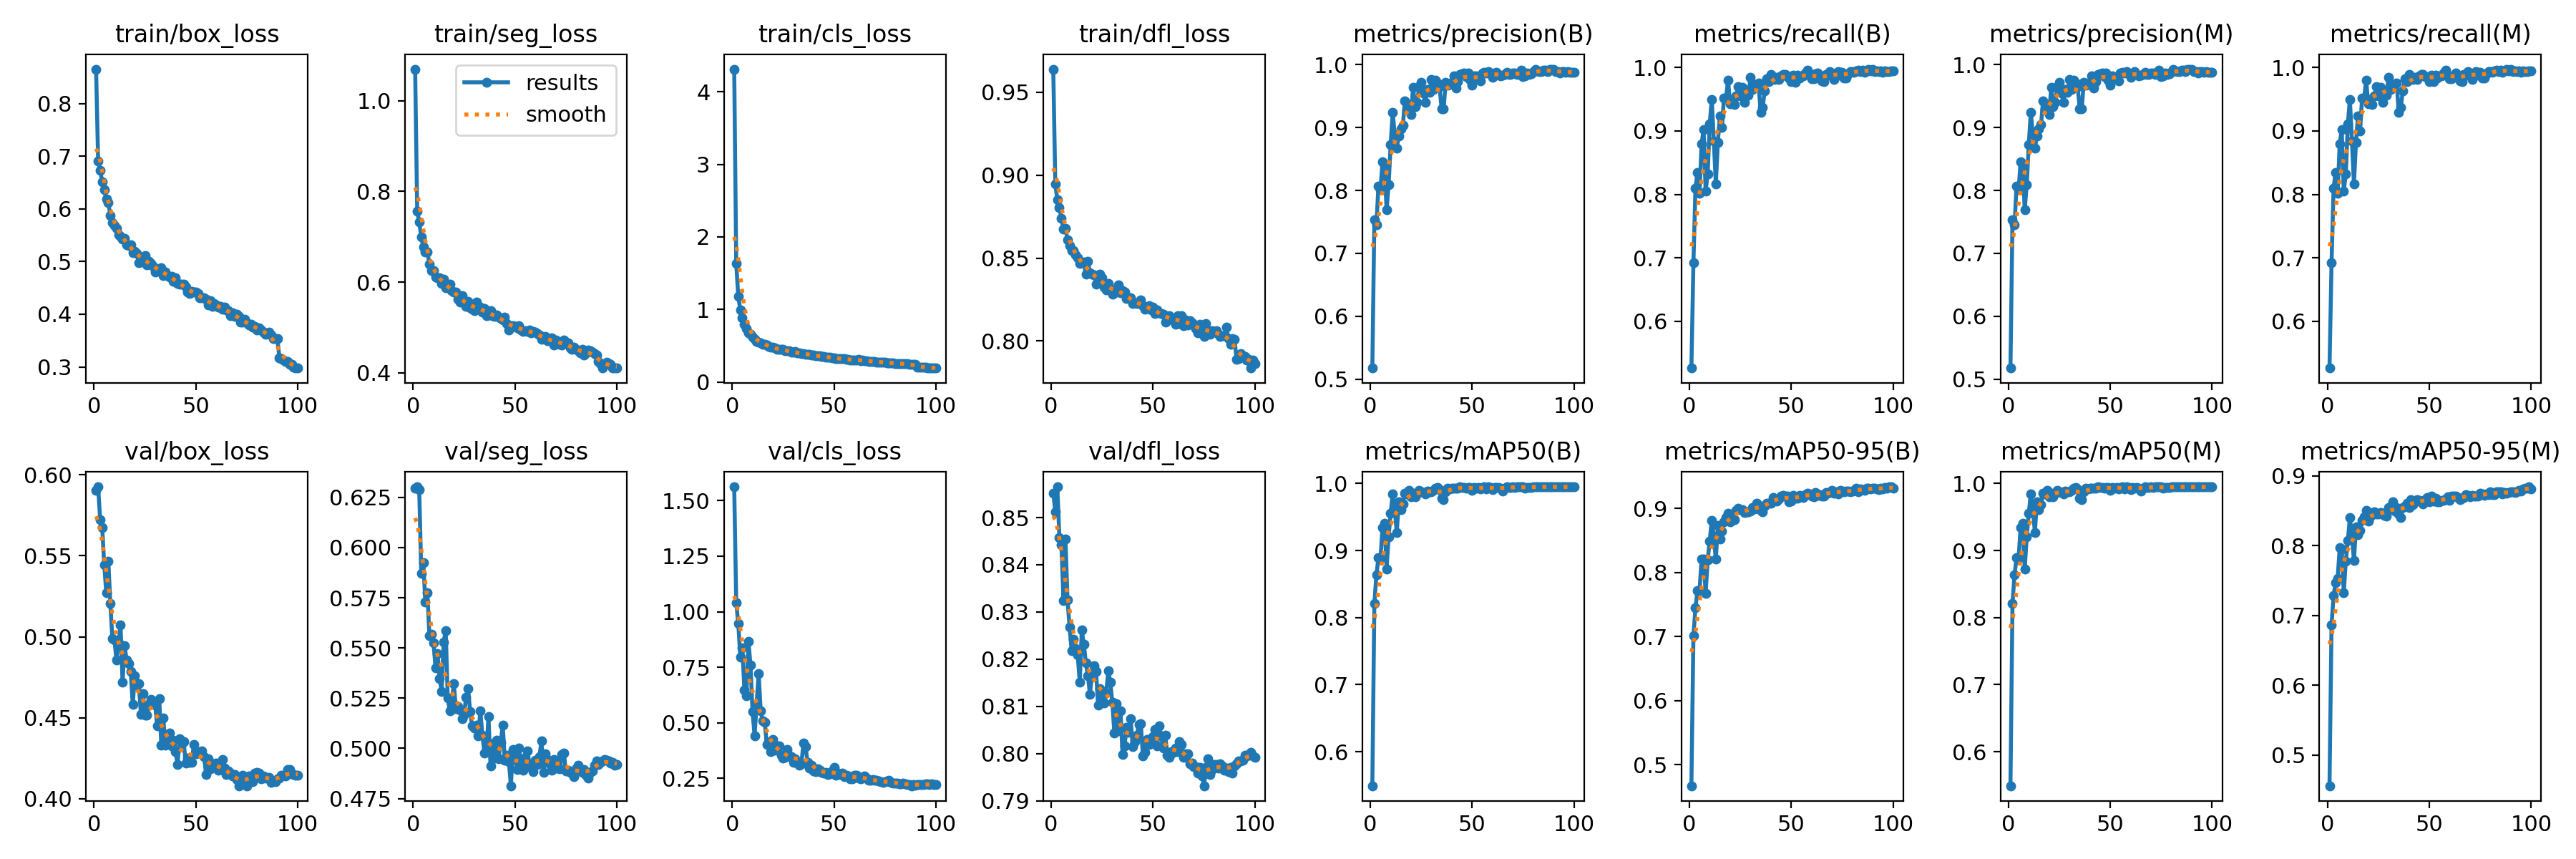

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/results.png', width=600)

# **Validation**

/content


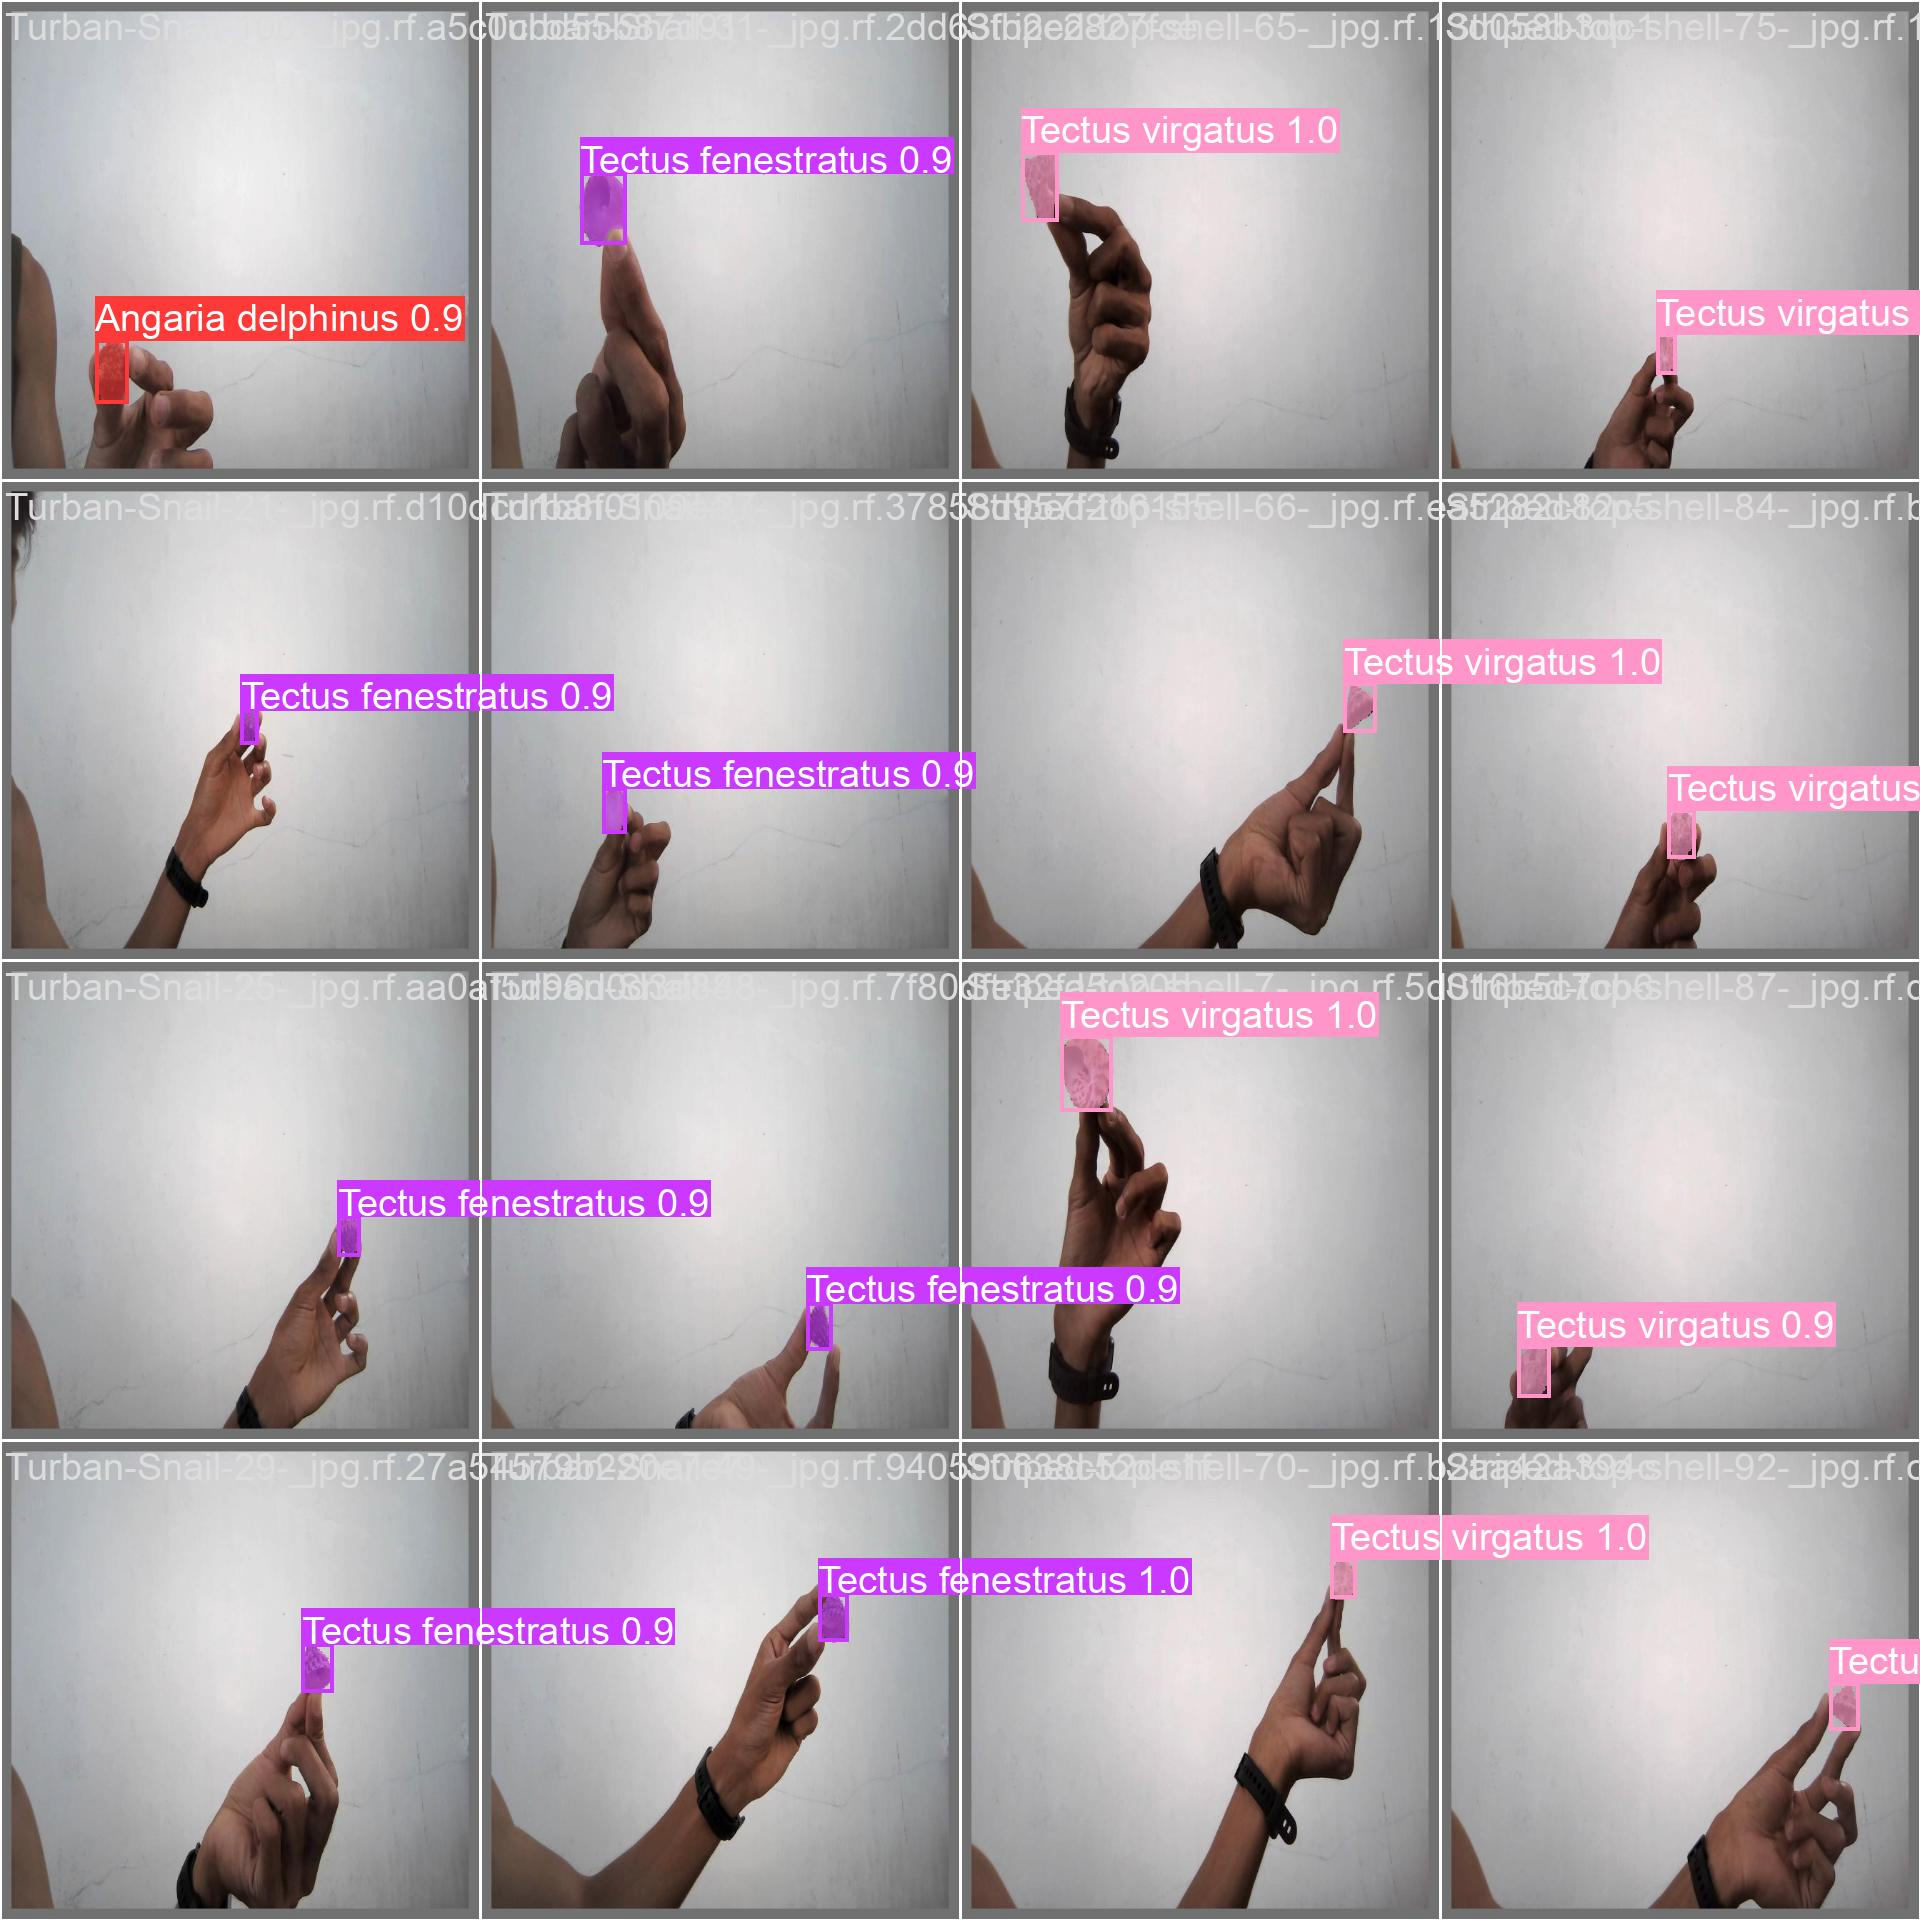

In [ ]:
%cd {HOME}
Image(filename=f'{HOME}/runs/segment/train/val_batch0_pred.jpg', width=600)

In [ ]:
#%cd {HOME}
#Image(filename=f'{HOME}/runs/segment/train/val_batch1_pred.jpg', width=600)

In [ ]:
#%cd {HOME}
#Image(filename=f'{HOME}/runs/segment/train/val_batch2_pred.jpg', width=600)

# **Validate Gastropod Detection & Classification Model**

In [ ]:
%cd {HOME}

!yolo task=segment mode=val model={HOME}/runs/segment/train/weights/best.pt data={dataset.location}/data.yaml

/content
Ultralytics YOLOv8.0.196 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla T4, 15102MiB)
YOLOv8s-seg summary (fused): 195 layers, 11788501 parameters, 0 gradients, 42.5 GFLOPs
val: Scanning /content/datasets/Species_Gastropod-Seg-3/valid/labels.cache... 460 images, 0 backgrounds, 0 corrupt: 100% 460/460 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% 29/29 [00:09<00:00,  3.19it/s]
                   all        460        460      0.988      0.995      0.995      0.934      0.988      0.995      0.995      0.875
     Angaria delphinus        460         20      0.952          1      0.995       0.99      0.952          1      0.995      0.958
     Canarium labiatum        460         20      0.952          1      0.993      0.926      0.952          1      0.993      0.885
     Cantharus fumosus        460         20       0.99          1      0.995      0.943       0.99  

**Inference with Gastropod Detection & Classification Model**

In [ ]:
#%cd {HOME}
#!yolo task=segment mode=predict model={HOME}/runs/segment/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=true

In [ ]:
#import glob
#from IPython.display import Image, display

#for image_path in glob.glob(f'{HOME}/runs/detect/predict/*.jpg')[:20]:
#      display(Image(filename=image_path, height=600))
#      print("\n")

**Save & Deploy Model**

In [ ]:
#project.version(dataset.version).deploy(model_type="yolov8s-seg", model_path=f"{HOME}/runs/segment/train/")